# **Proyecto Aprendizaje Automático**


*   **Andrea Aranda**
*   **Mariana Sambucetti**


--------------------
## **Contexto:**
--------------------

En la actualidad, es muy común comprar y vender productos a través de plataformas digitales como los marketplaces. Uno de los más utilizados en América Latina es el marketplace de Mercado Libre, una plataforma online que funciona como un gran centro comercial virtual donde vendedores y compradores se encuentran para realizar transacciones de productos y servicios.

A diferencia de una tienda con inventario propio, Mercado Libre actúa como intermediario, ofreciendo un espacio donde miles de vendedores independientes —desde particulares hasta grandes empresas— publican sus artículos y gestionan sus ventas mediante las soluciones de pago y envío que brinda la plataforma.

Debido a la enorme cantidad de publicaciones que se generan diariamente, resulta fundamental poder clasificar automáticamente si un artículo es nuevo o usado, ya que esto permite mejorar la organización del catálogo, la precisión de los filtros de búsqueda y la experiencia de los usuarios.

Este proyecto utiliza un dataset real de publicaciones de Mercado Libre Argentina, donde cada fila representa un anuncio individual. Los textos de estas publicaciones (títulos y descripciones) presentan una gran variabilidad en su redacción: errores tipográficos, repeticiones, símbolos, emojis, enlaces y lenguaje mixto.
Por este motivo, el desafío inicial consiste en aplicar un proceso riguroso de limpieza, y análisis exploratorio, como paso previo a la construcción de un modelo de clasificación supervisada que permita distinguir entre publicaciones de productos nuevos (“new”) y usados (“used”).



---------------------------
## **Objetivo:**
----------------------------

El objetivo principal de este proyecto es entrenar un modelo de clasificación supervisado, específicamente una regresión logística, capaz de predecir si una publicación de marketplace corresponde a un artículo nuevo (“new”) o usado (“used”), utilizando como insumo principal la información disponible de los anuncios, como los títulos y las descripciones, entre muchas otras variables. La variable objetivo seleccionada para este proyecto es 'condition', y será el eje de la modelización.

En esta primera etapa se realizará un trabajo exhaustivo de limpieza y análisis exploratorio de los datos (EDA), con el fin de comprender la estructura y el contenido, identificar patrones y preparar un conjunto de datos de calidad que permita, en fases posteriores, aplicar técnicas de Machine Learning para lograr la clasificación automática de las publicaciones.



---------------------------
## **Objetivo Especifico:**
----------------------------
Realizar el análisis exploratorio, limpieza y transformación de los datos.

Construir y seleccionar variables relevantes para mejorar el poder predictivo del modelo.

Entrenar y comparar al menos tres modelos de clasificación binaria: Regresión Logística, Support Vector Machine (SVM) y Random Forest, utilizando métricas como accuracy y F1-score.

Ajustar los hiperparámetros de un modelo con buen desempeño y eficiencia computacional (en nuestro caso, Random Forest), mediante técnicas de validación cruzada (GridSearchCV), con el objetivo de optimizar su performance sin incrementar en exceso el costo computacional.

Interpretar los resultados del modelo final, analizando la importancia de las variables que más influyen en la probabilidad de que un producto sea nuevo o usado.

---------------------------------
## **Meta Data:**
---------------------------------

El conjunto de datos utilizado en este proyecto proviene del marketplace de Mercado Libre Argentina y contiene información sobre publicaciones realizadas por distintos vendedores en la plataforma.  
Cada fila representa una publicación individual y describe las características de un artículo ofrecido a la venta, incluyendo su texto, categoría y estado (nuevo o usado), entre otros.

En total, el dataset cuenta con 100.000 observaciones y 48 columnas, que abarcan tanto información textual (títulos y descripciones) como variables categóricas y numéricas relacionadas con las publicaciones.

Los datos presentan un alto grado de variabilidad y desorden, ya que fueron generados por usuarios de forma libre. Esto se refleja en la presencia de errores ortográficos, abreviaciones, emojis, repeticiones, etiquetas HTML, enlaces y texto en diferentes idiomas.  
Por este motivo, la primera fase del proyecto se centra en aplicar un proceso riguroso de limpieza y preprocesamiento, con el objetivo de preparar los datos para su análisis y futura modelización.

Las columnas del dataset son las siguientes:

* seller_address  
* warranty  
* sub_status  
* **condition** **- Variable objetivo a predecir**  
* seller_contact  
* deal_ids  
* base_price  
* shipping  
* non_mercado_pago_payment_methods  
* seller_id  
* variations  
* location  
* site_id  
* listing_type_id  
* price  
* attributes  
* buying_mode  
* tags  
* listing_source  
* parent_item_id  
* coverage_areas  
* category_id  
* descriptions  
* last_updated  
* international_delivery_mode  
* pictures  
* id  
* official_store_id  
* differential_pricing  
* accepts_mercadopago  
* original_price  
* currency_id  
* thumbnail  
* title  
* automatic_relist  
* date_created  
* secure_thumbnail  
* stop_time  
* status  
* video_id  
* catalog_product_id  
* subtitle  
* initial_quantity  
* start_time  
* permalink  
* geolocation  
* sold_quantity  
* available_quantity

## **Importamos las librerías que vamos a necesitar**

In [ ]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Muestra todas las columnas del DataFrame sin cortar
pd.set_option("display.max_columns", None)

# Muestra hasta 100 filas del DataFrame
pd.set_option("display.max_rows", 100)

# Configuración general - Oculta los mensajes de advertencia para mantener el notebook más limpio
import warnings
import ast
warnings.filterwarnings("ignore")


## **Importamos el dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_original = pd.read_excel('/content/drive/MyDrive/UTEC - Aprendizaje Automatico/Proyecto/challenge.xlsx')

In [ ]:
# Hacemos una copia del dataset original para evitar modificarlo y trabajamos sobre esta copia.
data = data_original.copy()

## **Preprocesamiento de los datos**

### **Vemos las primeras y ultimas filas del dataset**

In [ ]:
# Muestra todas las filas que están duplicadas (excepto la primera ocurrencia)
duplicadas = data[data.duplicated(keep=False)]

# Ver las primeras 10 duplicadas
duplicadas.head(10)


,seller_address,warranty,sub_status,condition,seller_contact,deal_ids,base_price,shipping,non_mercado_pago_payment_methods,seller_id,variations,location,site_id,listing_type_id,price,attributes,buying_mode,tags,listing_source,parent_item_id,coverage_areas,category_id,descriptions,last_updated,international_delivery_mode,pictures,id,official_store_id,differential_pricing,accepts_mercadopago,original_price,currency_id,thumbnail,title,automatic_relist,date_created,secure_thumbnail,stop_time,status,video_id,catalog_product_id,subtitle,initial_quantity,start_time,permalink,geolocation,sold_quantity,available_quantity


In [ ]:
data.head()

,seller_address,warranty,sub_status,condition,seller_contact,deal_ids,base_price,shipping,non_mercado_pago_payment_methods,seller_id,variations,location,site_id,listing_type_id,price,attributes,buying_mode,tags,listing_source,parent_item_id,coverage_areas,category_id,descriptions,last_updated,international_delivery_mode,pictures,id,official_store_id,differential_pricing,accepts_mercadopago,original_price,currency_id,thumbnail,title,automatic_relist,date_created,secure_thumbnail,stop_time,status,video_id,catalog_product_id,subtitle,initial_quantity,start_time,permalink,geolocation,sold_quantity,available_quantity
0,"{'comment': '', 'longitude': -58.3986709, 'id'...",NaN,[],new,NaN,[],80.0,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",74952096,[],{},MLA,bronze,80.0,[],buy_it_now,['dragged_bids_and_visits'],NaN,MLA568261029,[],MLA126406,[{'id': 'MLA578052519-912855983'}],2015-09-05T20:42:58.000Z,none,"[{'size': '500x375', 'secure_url': 'https://a2...",MLA578052519,NaN,NaN,True,NaN,ARS,http://mla-s1-p.mlstatic.com/5386-MLA435206787...,Auriculares Samsung Originales Manos Libres Ca...,False,2015-09-05T20:42:53.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.co...,2015-11-04T20:42:53.000Z,active,NaN,NaN,NaN,1,2015-09-05T20:42:53.000Z,http://articulo.mercadolibre.com.ar/MLA-578052...,"{'latitude': -34.6280698, 'longitude': -58.398...",0,1
1,"{'comment': '', 'longitude': -58.5059173, 'id'...",NUESTRA REPUTACION,[],used,NaN,[],2650.0,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",42093335,[],{},MLA,silver,2650.0,[],buy_it_now,[],NaN,MLA561574487,[],MLA10267,[{'id': 'MLA581565358-930764806'}],2015-09-26T18:08:34.000Z,none,"[{'size': '499x334', 'secure_url': 'https://a2...",MLA581565358,NaN,NaN,True,NaN,ARS,http://mla-s1-p.mlstatic.com/23223-MLA20245018...,Cuchillo Daga Acero Carbón Casco Yelmo Solinge...,False,2015-09-26T18:08:30.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.co...,2015-11-25T18:08:30.000Z,active,NaN,NaN,NaN,1,2015-09-26T18:08:30.000Z,http://articulo.mercadolibre.com.ar/MLA-581565...,"{'latitude': -34.5935524, 'longitude': -58.505...",0,1
2,"{'comment': '', 'longitude': -58.4143948, 'id'...",NaN,[],used,NaN,[],60.0,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",133384258,[],{},MLA,bronze,60.0,[],buy_it_now,['dragged_bids_and_visits'],NaN,MLA568881256,[],MLA1227,[{'id': 'MLA578780872-916478256'}],2015-09-09T23:57:10.000Z,none,"[{'size': '375x500', 'secure_url': 'https://a2...",MLA578780872,NaN,NaN,True,NaN,ARS,http://mla-s1-p.mlstatic.com/22076-MLA20223367...,"Antigua Revista Billiken, N° 1826, Año 1954",False,2015-09-09T23:57:07.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.co...,2015-11-08T23:57:07.000Z,active,NaN,NaN,NaN,1,2015-09-09T23:57:07.000Z,http://articulo.mercadolibre.com.ar/MLA-578780...,"{'latitude': -34.6233907, 'longitude': -58.414...",0,1
3,"{'comment': '', 'longitude': -58.4929208, 'id'...",NaN,[],new,NaN,[],580.0,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",143001605,[],{},MLA,silver,580.0,[],buy_it_now,[],NaN,NaN,[],MLA86345,[{'id': 'MLA581877385-932309698'}],2015-10-05T16:03:50.306Z,none,"[{'size': '441x423', 'secure_url': 'https://a2...",MLA581877385,NaN,NaN,True,NaN,ARS,http://mla-s2-p.mlstatic.com/183901-MLA2043288...,Alarma Guardtex Gx412 Seguridad Para El Automo...,False,2015-09-28T18:47:56.000Z,https://a248.e.akamai.net/mla-s2-p.mlstatic.co...,2015-12-04T01:13:16.000Z,active,NaN,NaN,NaN,1,2015-09-28T18:47:56.000Z,http://articulo.mercadolibre.com.ar/MLA-581877...,"{'latitude': -34.6281894, 'longitude': -58.492...",0,1
4,"{'comment': '', 'longitude': -58.5495042, 'id'...",MI REPUTACION.,[],used,NaN,[],30.0,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",96873449,[],{},MLA,bronze,30.0,[],buy_it_now,['dragged_bi

In [ ]:
data.tail(5)

,seller_address,warranty,sub_status,condition,seller_contact,deal_ids,base_price,shipping,non_mercado_pago_payment_methods,seller_id,variations,location,site_id,listing_type_id,price,attributes,buying_mode,tags,listing_source,parent_item_id,coverage_areas,category_id,descriptions,last_updated,international_delivery_mode,pictures,id,official_store_id,differential_pricing,accepts_mercadopago,original_price,currency_id,thumbnail,title,automatic_relist,date_created,secure_thumbnail,stop_time,status,video_id,catalog_product_id,subtitle,initial_quantity,start_time,permalink,geolocation,sold_quantity,available_quantity
99995,"{'comment': '', 'longitude': -58.6142895, 'id'...",NaN,[],used,NaN,[],30.0,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",86277472,[],{},MLA,free,30.0,[],buy_it_now,['dragged_bids_and_visits'],NaN,MLA574054280,[],MLA41287,[{'id': 'MLA581735252-931637959'}],2015-09-28T01:05:00.000Z,none,"[{'size': '500x375', 'secure_url': 'https://a2...",MLA581735252,NaN,NaN,True,NaN,ARS,http://mla-s2-p.mlstatic.com/312-MLA4679861514...,El Corazon De Las Tinieblas - Conrad - Bibliot...,False,2015-09-28T01:04:49.000Z,https://a248.e.akamai.net/mla-s2-p.mlstatic.co...,2015-11-27T01:04:49.000Z,active,NaN,NaN,NaN,1,2015-09-28T01:04:49.000Z,http://articulo.mercadolibre.com.ar/MLA-581735...,"{'latitude': -34.4893206, 'longitude': -58.614...",0,1
99996,"{'comment': '', 'longitude': '', 'id': 1114571...",NaN,[],new,NaN,[],239.0,"{'local_pick_up': False, 'methods': [], 'tags'...","[{'description': 'Tarjeta de crédito', 'id': '...",120301324,[],{},MLA,bronze,239.0,[],buy_it_now,[],NaN,MLA546779779,[],MLA1614,[{'id': 'MLA579045843-917988491'}],2015-09-11T18:09:04.000Z,none,"[{'size': '500x375', 'secure_url': 'https://a2...",MLA579045843,NaN,NaN,True,NaN,ARS,http://mla-s1-p.mlstatic.com/5436-MLA496631021...,Juego De Toalla Y Toallon Franco Valente Var...,False,2015-09-11T18:09:02.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.co...,2015-11-10T18:09:02.000Z,active,NaN,NaN,NaN,5,2015-09-11T18:09:02.000Z,http://articulo.mercadolibre.com.ar/MLA-579045...,"{'latitude': '', 'longitude': ''}",0,5
99997,"{'comment': '', 'longitude': -58.6241199, 'id'...",NaN,[],used,NaN,[],600.0,"{'local_pick_up': False, 'methods': [], 'tags'...",[],12147240,[{'attribute_combinations': [{'value_id': '920...,{},MLA,bronze,600.0,"[{'value_id': 'male', 'attribute_group_id': 'D...",buy_it_now,[],NaN,NaN,[],MLA24696,[{'id': 'MLA578170688-913473882'}],2015-09-06T22:29:45.000Z,none,"[{'size': '500x375', 'secure_url': 'https://a2...",MLA578170688,NaN,NaN,True,NaN,ARS,http://mla-s2-p.mlstatic.com/990801-MLA2040843...,Campera De Cuero Negra,False,2015-09-06T22:29:30.000Z,https://a248.e.akamai.net/mla-s2-p.mlstatic.co...,2015-11-05T22:29:38.000Z,active,NaN,NaN,NaN,1,2015-09-06T22:29:30.000Z,http://articulo.mercadolibre.com.ar/MLA-578170...,"{'latitude': -34.6467858, 'longitude': -58.624...",0,1
99998,"{'comment': '', 'longitude': -58.4020374, 'id'...","Buen estado, se verifica al entregar. la total...",[],used,NaN,[],50.0,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",86102489,[],{},MLA,bronze,50.0,[],buy_it_now,['dragged_bids_and_visits'],NaN,MLA565452340,[],MLA34202,[{'id': 'MLA575062152-897880642'}],2015-08-18T17:23:33.000Z,none,"[{'size': '387x500', 'secure_url': 'https://a2...",MLA575062152,NaN,NaN,True,NaN,ARS,http://mla-s1-p.mlstatic.com/20035-MLA20182741...,"Psicodrama Y Teatro Moderno, Jean Fanchette. F2",False,2015-08-18T17:22:28.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.co...,2015-10-17T17:22:28.000Z,active,NaN,NaN,NaN,1,2015-08-18T17:22:28.000Z,http://articulo.mercadolibre.com.ar/MLA-575062...,"{'latitude': -34.6100093, 'longitude': -58.402...",0,1
99999,"{'comment': '', 'longitude': -58.3713681, 'id'...",NaN,[],used,NaN,[],75.0,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",39061148,[],{}

In [ ]:
data.columns.tolist()

['seller_address',
 'warranty',
 'sub_status',
 'condition',
 'seller_contact',
 'deal_ids',
 'base_price',
 'shipping',
 'non_mercado_pago_payment_methods',
 'seller_id',
 'variations',
 'location',
 'site_id',
 'listing_type_id',
 'price',
 'attributes',
 'buying_mode',
 'tags',
 'listing_source',
 'parent_item_id',
 'coverage_areas',
 'category_id',
 'descriptions',
 'last_updated',
 'international_delivery_mode',
 'pictures',
 'id',
 'official_store_id',
 'differential_pricing',
 'accepts_mercadopago',
 'original_price',
 'currency_id',
 'thumbnail',
 'title',
 'automatic_relist',
 'date_created',
 'secure_thumbnail',
 'stop_time',
 'status',
 'video_id',
 'catalog_product_id',
 'subtitle',
 'initial_quantity',
 'start_time',
 'permalink',
 'geolocation',
 'sold_quantity',
 'available_quantity']

###

### **Chequeamos valores duplicados**

In [ ]:
data.duplicated().sum()

np.int64(0)

Comprobamos que el dataset no tiene valores duplicados

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   seller_address                    100000 non-null  object 
 1   warranty                          39103 non-null   object 
 2   sub_status                        100000 non-null  object 
 3   condition                         100000 non-null  object 
 4   seller_contact                    2219 non-null    object 
 5   deal_ids                          100000 non-null  object 
 6   base_price                        100000 non-null  float64
 7   shipping                          100000 non-null  object 
 8   non_mercado_pago_payment_methods  100000 non-null  object 
 9   seller_id                         100000 non-null  int64  
 10  variations                        100000 non-null  object 
 11  location                          100000 non-null  ob

In [ ]:
data.isnull().sum()/len(data)

,0
seller_address,0.00000
warranty,0.60897
sub_status,0.00000
condition,0.00000
seller_contact,0.97781
deal_ids,0.00000
base_price,0.00000
shipping,0.00000
non_mercado_pago_payment_methods,0.00000
seller_id,0.00000


### **Transformamos la variable 'warranty' a cantidad de meses de garantia que tiene.**

In [ ]:
data['warranty'].value_counts()

,count
warranty,
Sí,5682
Sin garantía,5442
SI,592
6 meses,547
6 MESES,397
...,...
Garantia 1 AÑO,1
La garantía es oficial de Samsung,1
Garantía de 1 año del Fabricante.,1


In [ ]:
data['warranty'].nunique()

10263

In [ ]:
# Pasamos todo a texto en minúsculas y eliminamos espacios
data['warranty'] = data['warranty'].astype(str).str.lower().str.strip()


In [ ]:
warranty_months = []

for raw in data['warranty']:
    # Pasamos a texto y minúsculas
    w = str(raw).lower().strip()

    # 1) S   o 'sí' por defecto le asignamos 6 meses, que es el minimo legal en Argentina.
    if w in ['si', 'sí']:
        warranty_months.append(6)
        continue

    # 2) Garantía en MESES: "12 meses", "6 meses", etc.
    if 'mes' in w:
        partes = w.split()
        numero = None
        for p in partes:
            if p.isdigit():
                numero = int(p)
                break
        if numero is not None:
            warranty_months.append(numero)
        else:
            warranty_months.append(0)
        continue

    # 3) Garantía en AÑOS: "1 año", "2 anos", "3 años", etc.
    if 'año' in w or 'ano' in w:
        partes = w.split()
        numero = None
        for p in partes:
            if p.isdigit():
                numero = int(p) * 12
                break
        if numero is not None:
            warranty_months.append(numero)
        else:
            warranty_months.append(0)
        continue

    # 4) Garantía en DÍAS: "90 días", etc.
    if 'dia' in w or 'día' in w:
        partes = w.split()
        numero = None
        for p in partes:
            if p.isdigit():
                numero = round(int(p) / 30)
                break
        if numero is not None:
            warranty_months.append(numero)
        else:
            warranty_months.append(0)
        continue

    # 5) todo lo demás se le asigna 0 meses.
    warranty_months.append(0)

# Agregar columna al dataframe
data['warranty_months'] = warranty_months

# Verificar
data[['warranty', 'warranty_months']].head(20)


,warranty,warranty_months
0,nan,0
1,nuestra reputacion,0
2,nan,0
3,nan,0
4,mi reputacion.,0
5,sí,6
6,nan,0
7,nan,0
8,1 ano,12
9,nan,0


In [ ]:
# Vemos resultados
data[['warranty', 'warranty_months']].head(20)

,warranty,warranty_months
0,nan,0
1,nuestra reputacion,0
2,nan,0
3,nan,0
4,mi reputacion.,0
5,sí,6
6,nan,0
7,nan,0
8,1 ano,12
9,nan,0


In [ ]:
data['warranty'].nunique()

9403

In [ ]:
# Eliminamos la variable 'waranty' y nos qeudamos con 'warranty_months'
data.drop('warranty', axis=1, inplace=True)

In [ ]:
data['warranty_months'].value_counts()

,count
warranty_months,
0,85040
6,9857
12,1884
3,1133
1,486
24,292
60,288
2,239
36,139


Limpiamos la variable 'warranty' y creamos una nueva llamda 'warranty_months' donde capata los meses de garantia que tiene cada producto.


In [ ]:
data['seller_contact'].value_counts()

,count
seller_contact,
"{'area_code2': '', 'phone2': '', 'webpage': '', 'email': '', 'contact': '', 'area_code': '', 'other_info': '', 'phone': ''}",28
"{'area_code2': '', 'phone2': '', 'webpage': '', 'email': 'consultas_ml@xintel.com.ar', 'contact': 'Gustavo Piccione Propiedades', 'area_code': '011', 'other_info': '', 'phone': '4623-4723'}",19
"{'area_code2': '', 'phone2': '', 'webpage': '', 'email': 'info@calotpropiedades.com', 'contact': 'Calot Propiedades', 'area_code': '11', 'other_info': '', 'phone': '52722830'}",17
"{'area_code2': '', 'phone2': '', 'webpage': '', 'email': 'consultas_ml@xintel.com.ar', 'contact': 'Pablo Yaryura Propiedades', 'area_code': '', 'other_info': '', 'phone': '4750 0901 / 02 '}",14
"{'area_code2': '', 'phone2': '', 'webpage': '', 'email': 'consultas_ml@xintel.com.ar', 'contact': 'Alternativa propiedades', 'area_code': '011', 'other_info': '', 'phone': '5263 3535'}",13
...,...
"{'area_code2': '', 'phone2': '', 'webpage': '', 'email': '', 'contact': '', 'area_code': '', 'other_info': '', 'phone': '1165264910'}",1
"{'area_code2': '', 'phone2': '', 'webpage': '', 'email': '', 'contact': '', 'area_code': '', 'other_info': '', 'phone': '3875610857'}",1
"{'area_code2': '', 'phone2': '', 'webpage': '', 'email': '', 'contact': '', 'area_code': '11', 'other_info': '', 'phone': '58601629'}",1


La vamos a sacar, porque tiene solamente 1734 observaciones en 100000.

In [ ]:
data['listing_source'].value_counts()

,count
listing_source,


La vamos a sacar porque no tiene datos.

In [ ]:
data['parent_item_id'].value_counts()

,count
parent_item_id,
MLA570689700,1
MLA568261029,1
MLA561574487,1
MLA568881256,1
MLA566354576,1
...,...
MLA573253105,1
MLA579661808,1
MLA560824532,1


In [ ]:
data['parent_item_id'].nunique()

76989

La vamos a eliminar porque tiene datos faltanes y además no aporta información ya que los datos existentes son todos únicos.

### **Convertimos a binaria la variable 'official_store_id'**

In [ ]:
data['official_store_id'].value_counts()

,count
official_store_id,
197.0,37
84.0,29
371.0,25
158.0,24
216.0,21
...,...
178.0,1
426.0,1
239.0,1


In [ ]:
# Si tiene dato "si" (1 - Tienda oficial)
# Si está vacío (NaN) "no" (0 - No es tienda oficial)
# Mas abajo se le hace one-hot-encoding

data['official_store_id'] = np.where(data['official_store_id'].notna(), 'si', 'no')



In [ ]:
# Cambiamos el titulo a 'official_store'
data.rename(columns={'official_store_id': 'official_store'}, inplace=True)

In [ ]:
data['official_store'].value_counts()

,count
official_store,
no,99182
si,818


Transformamos la variable 'official_store_id' en binaria.
Si contiene datos es teinda oficial, "si", de lo contrario "no".

In [ ]:
data['differential_pricing'].value_counts()

,count
differential_pricing,


La vamos a sacar porque no tiene datos.

In [ ]:
data['original_price'].value_counts()

,count
original_price,
599.0,4
350.0,4
449.0,4
850.0,3
750.0,3
...,...
2699.0,1
1225.0,1
889.0,1


La vamos a sacar porque tiene solamente 114 observaciones en 100000.

In [ ]:
data['video_id'].value_counts()

,count
video_id,
QQNfOicE_o8,318
EVCQuwl7RIE,88
mYNRC5Ia1sk,37
U7okRYLuBNo,29
6JhmxwtTjoA,28
...,...
lfQQF7kf3wU,1
uIqDhO1iddo,1
GbI-Vwp1d2U,1


In [ ]:
data['video_id'].nunique()

2077

La vamos a sacar porque tiene solamente 2077 observaciones en 100000, además son todas únicas, no aportan información.

In [ ]:
data['catalog_product_id'].value_counts()

,count
catalog_product_id,
5093232.0,3
800744.0,1
3050291.0,1
5126117.0,1
94404.0,1
3051112.0,1
3053998.0,1
5113200.0,1
5434513.0,1


In [ ]:
data['catalog_product_id'].nunique()

9

La vamos a sacar porque tiene solamente 9 observaciones en 100000.

In [ ]:
data['subtitle'].value_counts()

,count
subtitle,


La vamos a sacar porque no tiene datos.

In [ ]:
data['deal_ids'].value_counts()

,count
deal_ids,
[],99760
['MLA58'],60
['MLA69'],41
['MLA60'],28
['MLA4'],28
['MLA70'],22
['MLA25'],7
['MLA3'],6
"['MLA70', 'MLA71']",6


In [ ]:
# Reemplazamos los '[]' por NaN
data['deal_ids'] = data['deal_ids'].replace('[]',  np.nan)

In [ ]:
data['deal_ids'].value_counts()

,count
deal_ids,
['MLA58'],60
['MLA69'],41
['MLA60'],28
['MLA4'],28
['MLA70'],22
['MLA25'],7
['MLA3'],6
"['MLA70', 'MLA71']",6
['MLA99'],5


### **Eliminamos las columnas con datos faltantes para facilitar el proceso de limpieza**

In [ ]:
data['thumbnail'].value_counts()

,count
thumbnail,
http://mla-s1-p.mlstatic.com/4446-MLA3620067895_012013-I.jpg,44
http://mla-s2-p.mlstatic.com/12089-MLA20053974504_022014-I.jpg,43
http://mla-s2-p.mlstatic.com/12049-MLA20053974515_022014-I.jpg,41
http://mla-s2-p.mlstatic.com/14376-MLA20085525316_042014-I.jpg,38
http://www.mercadolibre.com/jm/img?s=STC&v=I&f=proccesing_image_es.jpg,37
...,...
http://mla-s1-p.mlstatic.com/14822-MLA20090705318_052014-I.jpg,1
http://mla-s1-p.mlstatic.com/841901-MLA20445318447_102015-I.jpg,1
http://mla-s1-p.mlstatic.com/15939-MLA20111751231_062014-I.jpg,1


Thumbnail es la previsualización en miniatura de imagenes o URL. Es información visual, no numérica por lo tanto no nos aporta información. Lo eliminamos porque entendemos que no se puede usar en este modelo.

In [ ]:
data['secure_thumbnail'].value_counts()

,count
secure_thumbnail,
https://a248.e.akamai.net/mla-s1-p.mlstatic.com/4446-MLA3620067895_012013-I.jpg,44
https://a248.e.akamai.net/mla-s2-p.mlstatic.com/12089-MLA20053974504_022014-I.jpg,43
https://a248.e.akamai.net/mla-s2-p.mlstatic.com/12049-MLA20053974515_022014-I.jpg,41
https://a248.e.akamai.net/mla-s2-p.mlstatic.com/14376-MLA20085525316_042014-I.jpg,38
https://www.mercadolibre.com/jm/img?s=STC&v=I&f=proccesing_image_es.jpg,37
...,...
https://a248.e.akamai.net/mla-s1-p.mlstatic.com/14822-MLA20090705318_052014-I.jpg,1
https://a248.e.akamai.net/mla-s1-p.mlstatic.com/841901-MLA20445318447_102015-I.jpg,1
https://a248.e.akamai.net/mla-s1-p.mlstatic.com/15939-MLA20111751231_062014-I.jpg,1


Secure Thumbnail hace segura la previsualización en miniatura, no nos aporta información al igual que Thumbnail, por lo cual la eliminamos.

In [ ]:
data = data.drop(['seller_contact', 'deal_ids', 'listing_source', 'parent_item_id',
                  'differential_pricing', 'original_price', 'thumbnail', 'secure_thumbnail', 'video_id',
                  'catalog_product_id' , 'subtitle'], axis=1)

In [ ]:
data.isnull().sum()/len(data)

,0
seller_address,0.0
sub_status,0.0
condition,0.0
base_price,0.0
shipping,0.0
non_mercado_pago_payment_methods,0.0
seller_id,0.0
variations,0.0
location,0.0
site_id,0.0


In [ ]:
# Chequeamos que se hayan eliminado correctamente
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 37 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   seller_address                    100000 non-null  object 
 1   sub_status                        100000 non-null  object 
 2   condition                         100000 non-null  object 
 3   base_price                        100000 non-null  float64
 4   shipping                          100000 non-null  object 
 5   non_mercado_pago_payment_methods  100000 non-null  object 
 6   seller_id                         100000 non-null  int64  
 7   variations                        100000 non-null  object 
 8   location                          100000 non-null  object 
 9   site_id                           100000 non-null  object 
 10  listing_type_id                   100000 non-null  object 
 11  price                             100000 non-null  fl

In [ ]:
data['id'].value_counts()

,count
id,
MLA581762902,1
MLA580402613,1
MLA582997643,1
MLA577767321,1
MLA579864100,1
...,...
MLA576112692,1
MLA581877385,1
MLA578780872,1


In [ ]:
# Dejamos la columna 'id' como índice, ya que son todos valores únicos
data = data.set_index('id')

In [ ]:
data['sub_status'].value_counts()

,count
sub_status,
[],99014
['suspended'],966
['expired'],13
['deleted'],7


In [ ]:
# Reemplazamos los '[]' por NaN
data['sub_status'] = data['sub_status'].replace('[]',  np.nan)

In [ ]:
data['sub_status'].value_counts()

,count
sub_status,
['suspended'],966
['expired'],13
['deleted'],7


In [ ]:
data = data.drop(['sub_status'], axis=1)

Eliminamos la variable 'sub_status' ya que luego de sustituir caracteres, nos dimos cuenta que tiene muchos datos faltantes y no aporta a la prediccion del avariable objetivo.

In [ ]:
data['variations'].value_counts()

,count
variations,
[],91808
"[{'attribute_combinations': [{'value_id': '92028', 'name': 'Color Primario', 'value_name': 'Blanco', 'id': '83000'}, {'value_id': '131996', 'name': 'Talle', 'value_name': '18', 'id': '73002'}], 'seller_custom_field': None, 'picture_ids': ['262101-MLA20284580083_042015', '624101-MLA20284580082_042015'], 'sold_quantity': 0, 'available_quantity': 1, 'id': 9283307799, 'price': 50}]",1
"[{'attribute_combinations': [{'value_id': '91993', 'name': 'Color Primario', 'value_name': 'Rojo', 'id': '83000'}, {'value_id': '101996', 'name': 'Talle', 'value_name': 'L', 'id': '93000'}], 'seller_custom_field': None, 'picture_ids': ['507201-MLA20288771520_042015', '8326-MLA20003144372_112013'], 'sold_quantity': 0, 'available_quantity': 1, 'id': 9348089231, 'price': 200}]",1
"[{'attribute_combinations': [{'value_id': '92013', 'name': 'Color Primario', 'value_name': 'Azul', 'id': '83000'}, {'value_id': 'f6ac4409-c4bb-46d0-840a-917131133397', 'name': 'Talle', 'value_name': '3', 'id': '103000'}], 'seller_custom_field': None, 'picture_ids': ['318601-MLA20384025847_082015', '105701-MLA20384025926_082015', '616701-MLA20384027700_082015', '766601-MLA20384026376_082015', '616701-MLA20384027835_082015'], 'sold_quantity': 0, 'available_quantity': 1, 'id': 9281535238, 'price': 270}]",1
"[{'attribute_combinations': [{'value_id': '92025', 'name': 'Color Primario', 'value_name': 'Negro', 'id': '83000'}, {'value_id': '82061', 'name': 'Color Secundario', 'value_name': 'Blanco', 'id': '73001'}, {'value_id': '101995', 'name': 'Talle', 'value_name': 'M', 'id': '93000'}], 'seller_custom_field': None, 'picture_ids': ['14847-MLA20091187695_052014', '14863-MLA20091187720_052014', '14896-MLA20091187755_052014', '14824-MLA20091197920_052014'], 'sold_quantity': 0, 'available_quantity': 1, 'id': 9564108007, 'price': 220}]",1
...,...
"[{'attribute_combinations': [{'value_id': '92013', 'name': 'Color Primario', 'value_name': 'Azul', 'id': '83000'}, {'value_id': '82064', 'name': 'Talle', 'value_name': '36', 'id': '73002'}], 'seller_custom_field': None, 'picture_ids': ['307011-MLA20449545242_102015', '807011-MLA20449546128_102015', '768011-MLA20449546645_102015', '891011-MLA20449545353_102015'], 'sold_quantity': 0, 'available_quantity': 1, 'id': 9792791480, 'price': 200}]",1
"[{'attribute_combinations': [{'value_id': '92025', 'name': 'Color Primario', 'value_name': 'Negro', 'id': '83000'}], 'seller_custom_field': None, 'picture_ids': ['785101-MLA20269760973_032015'], 'sold_quantity': 3, 'available_quantity': 2, 'id': 9624646722, 'price': 730}, {'attribute_combinations': [{'value_id': '92025', 'name': 'Color Primario', 'value_name': 'Negro', 'id': '83000'}, {'value_id': '82033', 'name': 'Color Secundario', 'value_name': 'Marrón', 'id': '73001'}], 'seller_custom_field': None, 'picture_ids': ['967101-MLA20269761705_032015'], 'sold_quantity': 0, 'available_quantity': 5, 'id': 9624646724, 'price': 730}]",1
"[{'attribute_combinations': [{'value_id': '92021', 'name': 'Color Primario', 'value_name': 'Fucsia', 'id': '83000'}, {'value_id': '141999', 'name': 'Talle', 'value_name': '14', 'id': '103000'}], 'seller_custom_field': None, 'picture_ids': ['7656-MLA5252599495_102013', '6145-MLA4633528639_072013'], 'sold_quantity': 0, 'available_quantity': 1, 'id': 9777341848, 'price': 27}]",1


In [ ]:
# Reemplazamos los '[]' por NaN
data['variations'] = data['variations'].replace('[]',  np.nan)

In [ ]:
data['variations'].value_counts()

,count
variations,
"[{'attribute_combinations': [{'value_id': '92000', 'name': 'Color Primario', 'value_name': 'Marrón', 'id': '83000'}, {'value_id': '82077', 'name': 'Talle', 'value_name': '43', 'id': '73002'}], 'seller_custom_field': None, 'picture_ids': ['18963-MLA20162752825_092014', '18975-MLA20162752888_092014', '18971-MLA20162752922_092014', '18984-MLA20162754313_092014', '18973-MLA20162755523_092014', '18914-MLA20162755574_092014'], 'sold_quantity': 0, 'available_quantity': 1, 'id': 9803918861, 'price': 650}]",1
"[{'attribute_combinations': [{'value_id': '92028', 'name': 'Color Primario', 'value_name': 'Blanco', 'id': '83000'}, {'value_id': '132013', 'name': 'Talle', 'value_name': '33', 'id': '73002'}], 'seller_custom_field': None, 'picture_ids': ['326901-MLA20447992261_102015'], 'sold_quantity': 0, 'available_quantity': 1, 'id': 9779125023, 'price': 150}]",1
"[{'attribute_combinations': [{'value_id': '91994', 'name': 'Color Primario', 'value_name': 'Rosa', 'id': '83000'}, {'value_id': '82061', 'name': 'Color Secundario', 'value_name': 'Blanco', 'id': '73001'}, {'value_id': '141995', 'name': 'Talle', 'value_name': '6', 'id': '103000'}], 'seller_custom_field': None, 'picture_ids': ['15240-MLA20099010407_052014', '15211-MLA20099010710_052014', '15294-MLA20099010773_052014', '15277-MLA20099010843_052014', '15235-MLA20099012165_052014', '15214-MLA20099012622_052014'], 'sold_quantity': 0, 'available_quantity': 0, 'id': 9518984337, 'price': 480}, {'attribute_combinations': [{'value_id': '91994', 'name': 'Color Primario', 'value_name': 'Rosa', 'id': '83000'}, {'value_id': '82061', 'name': 'Color Secundario', 'value_name': 'Blanco', 'id': '73001'}, {'value_id': '141994', 'name': 'Talle', 'value_name': '4', 'id': '103000'}], 'seller_custom_field': None, 'picture_ids': ['15240-MLA20099010407_052014', '15211-MLA20099010710_052014', '15294-MLA20099010773_052014', '15277-MLA20099010843_052014', '15235-MLA20099012165_052014', '15214-MLA20099012622_052014'], 'sold_quantity': 0, 'available_quantity': 1, 'id': 9518984341, 'price': 480}]",1
"[{'attribute_combinations': [{'value_id': '92028', 'name': 'Color Primario', 'value_name': 'Blanco', 'id': '83000'}, {'value_id': '82047', 'name': 'Color Secundario', 'value_name': 'Celeste', 'id': '73001'}, {'value_id': '141996', 'name': 'Talle', 'value_name': '8', 'id': '103000'}], 'seller_custom_field': None, 'picture_ids': ['4104-MLA144132921_3760'], 'sold_quantity': 0, 'available_quantity': 1, 'id': 9305562478, 'price': 35}]",1
"[{'attribute_combinations': [{'value_id': '92025', 'name': 'Color Primario', 'value_name': 'Negro', 'id': '83000'}, {'value_id': '101995', 'name': 'Talle', 'value_name': 'M', 'id': '93000'}], 'seller_custom_field': None, 'picture_ids': ['986801-MLA20402285341_092015', '579701-MLA20402287129_092015', '243801-MLA20402287505_092015', '894801-MLA20402284929_092015', '762801-MLA20402284583_092015', '150801-MLA20401888460_092015'], 'sold_quantity': 0, 'available_quantity': 1, 'id': 9423910713, 'price': 990}]",1
...,...
"[{'attribute_combinations': [{'value_id': '92000', 'name': 'Color Primario', 'value_name': 'Marrón', 'id': '83000'}, {'value_id': '101995', 'name': 'Talle', 'value_name': 'M', 'id': '93000'}], 'seller_custom_field': None, 'picture_ids': ['19565-MLA20174256933_102014', '19659-MLA20174258572_102014', '19618-MLA20174258680_102014'], 'sold_quantity': 0, 'available_quantity': 1, 'id': 9433998290, 'price': 1650}]",1
"[{'attribute_combinations': [{'value_id': '92013', 'name': 'Color Primario', 'value_name': 'Azul', 'id': '83000'}, {'value_id': '101995', 'name': 'Talle', 'value_name': 'M', 'id': '93000'}], 'seller_custom_field': None, 'picture_ids': ['21897-MLA20219050871_122014', '21826-MLA20219051350_122014', '21894-MLA20219051403_122014', '21871-MLA20219051434_122014', '17709-MLA20142698862_082014'], 'sold_quantity': 1, 'available_quantity': 2, 'id': 9391988875, 'price': 590}, {'attribute_combinations': [{'value_id': '92013', 'name': 'Color Primario', 'value_name':

In [ ]:
data = data.drop(['variations'], axis=1)

Eliminamos la variable 'variations' ya que luego de sustituir caracteres, nos dimos cuenta que tiene muchos datos faltantes y pensamos no aporta infomracion para la predicion.

In [ ]:
data['location'].value_counts()

,count
location,
{},97781
"{'open_hours': '', 'neighborhood': {'name': 'Liniers', 'id': 'TUxBQkxJTjEzNTha'}, 'longitude': '', 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': '', 'zip_code': '', 'city': {'name': 'Capital Federal', 'id': 'TUxBQ0NBUGZlZG1sYQ'}, 'state': {'name': 'Capital Federal', 'id': 'TUxBUENBUGw3M2E1'}}",29
"{'open_hours': '', 'neighborhood': {'name': 'Villa Devoto', 'id': 'TUxBQlZJTDYzNzZa'}, 'longitude': '', 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': '', 'zip_code': '', 'city': {'name': 'Capital Federal', 'id': 'TUxBQ0NBUGZlZG1sYQ'}, 'state': {'name': 'Capital Federal', 'id': 'TUxBUENBUGw3M2E1'}}",27
"{'open_hours': '', 'neighborhood': {'name': 'Villa Urquiza', 'id': 'TUxBQlZJTDcwOTla'}, 'longitude': '', 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': '', 'zip_code': '', 'city': {'name': 'Capital Federal', 'id': 'TUxBQ0NBUGZlZG1sYQ'}, 'state': {'name': 'Capital Federal', 'id': 'TUxBUENBUGw3M2E1'}}",25
"{'open_hours': '', 'neighborhood': {'name': 'Belgrano', 'id': 'TUxBQkJFTDcyNTJa'}, 'longitude': '', 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': '', 'zip_code': '', 'city': {'name': 'Capital Federal', 'id': 'TUxBQ0NBUGZlZG1sYQ'}, 'state': {'name': 'Capital Federal', 'id': 'TUxBUENBUGw3M2E1'}}",24
...,...
"{'open_hours': '', 'neighborhood': {'name': 'Merlo', 'id': 'TUxBQk1FUjk0Mjda'}, 'longitude': -58.7215841, 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': 'GUARDIA VIEJA 900', 'latitude': -34.6569491, 'zip_code': '', 'city': {'name': 'Merlo', 'id': 'TUxBQ01FUmUyYWZl'}, 'state': {'name': 'Bs.as. G.b.a. Oeste', 'id': 'TUxBUEdSQWVmNTVm'}}",1
"{'open_hours': '', 'neighborhood': {'name': 'Villa Lugano', 'id': 'TUxBQlZJTDQ4MzBa'}, 'longitude': -58.4757071, 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': 'Cosquin 4800', 'latitude': -34.6859843, 'zip_code': '', 'city': {'name': 'Capital Federal', 'id': 'TUxBQ0NBUGZlZG1sYQ'}, 'state': {'name': 'Capital Federal', 'id': 'TUxBUENBUGw3M2E1'}}",1
"{'open_hours': '', 'neighborhood': {'name': 'Lanús Este', 'id': 'TUxBQkxBTjQ3NDFa'}, 'longitude': '', 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': 'PRINGLES 2700', 'latitude': '', 'zip_code': '', 'city': {'name': 'Lanús', 'id': 'TUxBQ0xBTmJjYzE4'}, 'state': {'name': 'Bs.as. G.b.a. Sur', 'id': 'TUxBUEdSQXJlMDNm'}}",1


In [ ]:
# Reemplazamos los '{}' por NaN
data['location'] = data['location'].replace('{}',  np.nan)

In [ ]:
data['location'].value_counts()

,count
location,
"{'open_hours': '', 'neighborhood': {'name': 'Liniers', 'id': 'TUxBQkxJTjEzNTha'}, 'longitude': '', 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': '', 'zip_code': '', 'city': {'name': 'Capital Federal', 'id': 'TUxBQ0NBUGZlZG1sYQ'}, 'state': {'name': 'Capital Federal', 'id': 'TUxBUENBUGw3M2E1'}}",29
"{'open_hours': '', 'neighborhood': {'name': 'Villa Devoto', 'id': 'TUxBQlZJTDYzNzZa'}, 'longitude': '', 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': '', 'zip_code': '', 'city': {'name': 'Capital Federal', 'id': 'TUxBQ0NBUGZlZG1sYQ'}, 'state': {'name': 'Capital Federal', 'id': 'TUxBUENBUGw3M2E1'}}",27
"{'open_hours': '', 'neighborhood': {'name': 'Villa Urquiza', 'id': 'TUxBQlZJTDcwOTla'}, 'longitude': '', 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': '', 'zip_code': '', 'city': {'name': 'Capital Federal', 'id': 'TUxBQ0NBUGZlZG1sYQ'}, 'state': {'name': 'Capital Federal', 'id': 'TUxBUENBUGw3M2E1'}}",25
"{'open_hours': '', 'neighborhood': {'name': 'Belgrano', 'id': 'TUxBQkJFTDcyNTJa'}, 'longitude': '', 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': '', 'zip_code': '', 'city': {'name': 'Capital Federal', 'id': 'TUxBQ0NBUGZlZG1sYQ'}, 'state': {'name': 'Capital Federal', 'id': 'TUxBUENBUGw3M2E1'}}",24
"{'open_hours': '', 'neighborhood': {'name': 'San Miguel', 'id': 'TUxBQlNBTjYxNjla'}, 'longitude': '', 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': '', 'zip_code': '', 'city': {'name': 'San Miguel', 'id': 'TUxBQ1NBTm1pZ3VlbA'}, 'state': {'name': 'Bs.as. G.b.a. Norte', 'id': 'TUxBUEdSQWU4ZDkz'}}",19
...,...
"{'open_hours': '', 'neighborhood': {'name': 'Pilar', 'id': 'TUxBQlBJTDIzMjY0NQ'}, 'longitude': -58.5199663, 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': 'El Portal Pilar Mts. al 400', 'latitude': -34.6461244, 'zip_code': '', 'city': {'name': 'Pilar', 'id': 'TUxBQ1BJTGFyMTIz'}, 'state': {'name': 'Bs.as. G.b.a. Norte', 'id': 'TUxBUEdSQWU4ZDkz'}}",1
"{'open_hours': '', 'neighborhood': {'name': 'Pueyrredón', 'id': 'TUxBQlBVRTQ2MDAzNw'}, 'longitude': '', 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': '', 'zip_code': '', 'city': {'name': 'Pilar', 'id': 'TUxBQ1BJTGFyMTIz'}, 'state': {'name': 'Bs.as. G.b.a. Norte', 'id': 'TUxBUEdSQWU4ZDkz'}}",1
"{'open_hours': '', 'neighborhood': {'name': 'Puerto Iguazú', 'id': 'TUxBQlBVRTUzMzRa'}, 'longitude': -54.5681474, 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': 'pombero 100', 'latitude': -25.6033982, 'zip_code': '', 'city': {'name': 'Iguazú', 'id': 'TUxBQ0lHVTliYTA0'}, 'state': {'name': 'Misiones', 'id': 'TUxBUE1JU3MzNjIx'}}",1


In [ ]:
data = data.drop(['location'], axis=1)

Eliminamos la variable 'location' ya que luego de sustituir caracteres, nos dimos cuenta que tiene muchos datos faltantes

In [ ]:
data['attributes'].value_counts()

attributes
[]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [ ]:
# Reemplazamos los '[]' por NaN
data['attributes'] = data['attributes'].replace('[]',  np.nan)

In [ ]:
data['attributes'].nunique()

3452

In [ ]:
data['attributes'].isnull().sum()

np.int64(87575)

In [ ]:
data = data.drop(['attributes'], axis=1)

Eliminamos la variable 'attributes' ya que luego de sustituir caracteres, nos dimos cuenta que tiene muchos datos faltantes

In [ ]:
data['site_id'].value_counts()

,count
site_id,
MLA,100000


In [ ]:
data = data.drop(['site_id'], axis=1)

Todos los datos de la variable 'site_id' son de MLA, Mercado Libre Argentina, entonces no agrega valor.

In [ ]:
data['tags'].value_counts()

,count
tags,
['dragged_bids_and_visits'],72551
[],24910
"['good_quality_thumbnail', 'dragged_bids_and_visits']",1330
['dragged_visits'],516
['good_quality_thumbnail'],392
"['dragged_visits', 'free_relist']",285
"['poor_quality_thumbnail', 'dragged_bids_and_visits']",11
['poor_quality_thumbnail'],5


In [ ]:
data = data.drop(['tags'], axis=1)

Eliminamos la variable 'tags', no nos aporta información para predecir la variable objetivo.

In [ ]:
data['coverage_areas'].value_counts()

,count
coverage_areas,
[],100000


In [ ]:
data = data.drop(['coverage_areas'], axis=1)

Eliminamos la variable 'coverage_areas' porque no contiene datos.

In [ ]:
data['international_delivery_mode'].value_counts()

,count
international_delivery_mode,
none,100000


In [ ]:
data = data.drop(['international_delivery_mode'], axis=1)

La variable 'international_delivery_mode' la eliminamos porque no aporta información adicional,sólo nos confirma que todas las entregas son dentro de Argentina.

In [ ]:
data = data.drop(['pictures'], axis=1)

Eliminamos la variable 'pictures' porque no aporta información para predecir la variable objetivo.

In [ ]:
data['permalink'].value_counts()

,count
permalink,
http://articulo.mercadolibre.com.ar/MLA-581762902-sachs-amortiguador-suzuki-grandvitara-jiii-delantero-der-_JM,1
http://articulo.mercadolibre.com.ar/MLA-580402613-bermudas-mujer-de-algodon-_JM,1
http://articulo.mercadolibre.com.ar/MLA-582997643-adornos-para-tortas-en-porcelana-fria-boda-casamiento-novios-_JM,1
http://articulo.mercadolibre.com.ar/MLA-577767321-scanner-kodak-i2400-30-ppm-bncolor-1200dpi-duplex-_JM,1
http://articulo.mercadolibre.com.ar/MLA-579864100-un-caso-patologico-sanders-_JM,1
...,...
http://articulo.mercadolibre.com.ar/MLA-576112692-serenata-jennifer-blake-_JM,1
http://articulo.mercadolibre.com.ar/MLA-581877385-alarma-guardtex-gx412-seguridad-para-el-automotor-_JM,1
http://articulo.mercadolibre.com.ar/MLA-578780872-antigua-revista-billiken-n-1826-ano-1954-_JM,1


In [ ]:
data = data.drop(['permalink'], axis=1)

Eliminamos la variable 'permalink', porque son datos únicos de la publicación y no aporta información para predecir.

In [ ]:
Dif = pd.DataFrame(data['base_price'] - data['price'])
Dif.value_counts()

,count
0,
0.0,99971
-40.0,3
-10.0,3
-15.0,2
-6.5,2
-6584.0,1
-725.0,1
-784.0,1
-51.0,1


In [ ]:
data = data.drop(['base_price'], axis=1)

Luego de investigar la diferencia entre las variables 'base_price' y 'price', vemos que en un 99.9% no tienen diferencia. Los pocos productos que sí tienen diferencia, el precio baja. Nos vamos a quedar con la columna 'price'.

In [ ]:
data['accepts_mercadopago'].value_counts()

,count
accepts_mercadopago,
True,97781
False,2219


In [ ]:
data['accepts_mercadopago'] = data['accepts_mercadopago'].fillna(False)

# Pasar de booleano a binario 1=Si y 0=No
data['accepts_mercadopago'] = data['accepts_mercadopago'].astype(int)

In [ ]:
# Pasmaos 'accepts_mercadopago'a binaria. 1=Si y 0=No
data['accepts_mercadopago'].value_counts()

,count
accepts_mercadopago,
1,97781
0,2219


In [ ]:
data['currency_id'].value_counts()

,count
currency_id,
ARS,99433
USD,567


In [ ]:
# Definimos el tipo de cambio promedio del año 2015, que es el periodo de nuestra data (1 USD = 9,27 ARS)
usd_to_ars = 9.27 # Lo buscamos en el site del Banco Centrla de la República Argentina

# Multiplicamos los precios en USD por el tipo de cambio
data.loc[data['currency_id'] == 'USD', 'price'] = data.loc[data['currency_id'] == 'USD', 'price'] * usd_to_ars

# Cambiamos la etiqueta de moneda a ARS para esas filas
data.loc[data['currency_id'] == 'USD', 'currency_id'] = 'ARS'

In [ ]:
# Chequeamos que nos haya quedado todo en ARS
data['currency_id'].value_counts()

,count
currency_id,
ARS,100000


In [ ]:
data = data.drop(['currency_id', 'automatic_relist', 'initial_quantity'], axis=1)

Eliminamos las variables:

* 'currency_id' - la mayoría de las transacciones (99.4%) son en pesos argentinos, lo cual tiene sentido porque son en Argentina. Las transacciones en USD las pasamos a ARS.
* 'automatic_relist' - no aporta información para predecir la variable objetivo.
* 'initial_quantity' - muy similar a 'available_quantity' pero menos informativa.


In [ ]:
data['non_mercado_pago_payment_methods'].value_counts()

,count
non_mercado_pago_payment_methods,
[],30559
"[{'description': 'Transferencia bancaria', 'id': 'MLATB', 'type': 'G'}, {'description': 'Efectivo', 'id': 'MLAMO', 'type': 'G'}]",22536
"[{'description': 'Transferencia bancaria', 'id': 'MLATB', 'type': 'G'}, {'description': 'Tarjeta de crédito', 'id': 'MLAOT', 'type': 'N'}, {'description': 'Efectivo', 'id': 'MLAMO', 'type': 'G'}]",20776
"[{'description': 'Efectivo', 'id': 'MLAMO', 'type': 'G'}]",14325
"[{'description': 'Transferencia bancaria', 'id': 'MLATB', 'type': 'G'}, {'description': 'Acordar con el comprador', 'id': 'MLAWC', 'type': 'G'}, {'description': 'Efectivo', 'id': 'MLAMO', 'type': 'G'}]",2566
...,...
"[{'description': 'MasterCard', 'id': 'MLAMC', 'type': 'C'}, {'description': 'Mastercard Maestro', 'id': 'MLAMS', 'type': 'D'}, {'description': 'Visa Electron', 'id': 'MLAVE', 'type': 'D'}, {'description': 'Transferencia bancaria', 'id': 'MLATB', 'type': 'G'}, {'description': 'Tarjeta de crédito', 'id': 'MLAOT', 'type': 'N'}, {'description': 'Visa', 'id': 'MLAVS', 'type': 'C'}, {'description': 'Diners', 'id': 'MLADC', 'type': 'C'}, {'description': 'Acordar con el comprador', 'id': 'MLAWC', 'type': 'G'}, {'description': 'Efectivo', 'id': 'MLAMO', 'type': 'G'}, {'description': 'American Express', 'id': 'MLAAM', 'type': 'C'}]",1
"[{'description': 'MasterCard', 'id': 'MLAMC', 'type': 'C'}, {'description': 'Transferencia bancaria', 'id': 'MLATB', 'type': 'G'}, {'description': 'Tarjeta de crédito', 'id': 'MLAOT', 'type': 'N'}, {'description': 'Visa', 'id': 'MLAVS', 'type': 'C'}, {'description': 'Diners', 'id': 'MLADC', 'type': 'C'}, {'description': 'Giro postal', 'id': 'MLAWT', 'type': 'G'}, {'description': 'Efectivo', 'id': 'MLAMO', 'type': 'G'}, {'description': 'American Express', 'id': 'MLAAM', 'type': 'C'}]",1
"[{'description': 'MasterCard', 'id': 'MLAMC', 'type': 'C'}, {'description': 'Mastercard Maestro', 'id': 'MLAMS', 'type': 'D'}, {'description': 'Visa Electron', 'id': 'MLAVE', 'type': 'D'}, {'description': 'Transferencia bancaria', 'id': 'MLATB', 'type': 'G'}, {'description': 'Visa', 'id': 'MLAVS', 'type': 'C'}, {'description': 'Giro postal', 'id': 'MLAWT', 'type': 'G'}, {'description': 'Acordar con el comprador', 'id': 'MLAWC', 'type': 'G'}, {'description': 'Efectivo', 'id': 'MLAMO', 'type': 'G'}, {'description': 'American Express', 'id': 'MLAAM', 'type': 'C'}]",1


In [ ]:
# 1) Pasamos el texto a lista de diccionarios
def parse_payment_methods(x):
    if x == '[]' or pd.isna(x) or x == '':
        return []
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return x

data['non_mp_methods_list'] = data['non_mercado_pago_payment_methods'].apply(parse_payment_methods)

# 2) Obtenemos todos los métodos de pago distintos (por 'description')
all_methods = set()

for lista in data['non_mp_methods_list']:
    for d in lista:
        desc = d.get('description')
        if desc is not None:
            all_methods.add(desc)

print("Métodos de pago no MP encontrados:")
print(sorted(all_methods))

# 3) Creamos una columna binaria por cada método (multi-hot)
for desc in all_methods:
    col_name = "pm_" + (
        desc.lower()
           .replace(" ", "_")
           .replace("á", "a")
           .replace("é", "e")
           .replace("í", "i")
           .replace("ó", "o")
           .replace("ú", "u")
           .replace("ñ", "n")
    )

    data[col_name] = data['non_mp_methods_list'].apply(
        lambda lista, desc=desc: int(any(m.get('description') == desc for m in lista))
    )

Métodos de pago no MP encontrados:
['Acordar con el comprador', 'American Express', 'Cheque certificado', 'Contra reembolso', 'Diners', 'Efectivo', 'Giro postal', 'MasterCard', 'Mastercard Maestro', 'MercadoPago', 'Tarjeta de crédito', 'Transferencia bancaria', 'Visa', 'Visa Electron']


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, MLA578052519 to MLA580630011
Data columns (total 37 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   seller_address                    100000 non-null  object 
 1   condition                         100000 non-null  object 
 2   shipping                          100000 non-null  object 
 3   non_mercado_pago_payment_methods  100000 non-null  object 
 4   seller_id                         100000 non-null  int64  
 5   listing_type_id                   100000 non-null  object 
 6   price                             100000 non-null  float64
 7   buying_mode                       100000 non-null  object 
 8   category_id                       100000 non-null  object 
 9   descriptions                      100000 non-null  object 
 10  last_updated                      100000 non-null  object 
 11  official_store                    100000

In [ ]:
data = data.drop(['non_mercado_pago_payment_methods', 'non_mp_methods_list'], axis=1)

Eliminamos la variable 'non_mercado_pago_payment_methods' original y 'non_mp_methods_list' que es la modificada, ya que tenemos las nuevas variables creadas por metodo de pago 'pm_acordar_con_el_comprador', 'pm_mastercard', etc.

In [ ]:
# Chequeamos que eliminamos las columnas correctamente.
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, MLA578052519 to MLA580630011
Data columns (total 35 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   seller_address               100000 non-null  object 
 1   condition                    100000 non-null  object 
 2   shipping                     100000 non-null  object 
 3   seller_id                    100000 non-null  int64  
 4   listing_type_id              100000 non-null  object 
 5   price                        100000 non-null  float64
 6   buying_mode                  100000 non-null  object 
 7   category_id                  100000 non-null  object 
 8   descriptions                 100000 non-null  object 
 9   last_updated                 100000 non-null  object 
 10  official_store               100000 non-null  object 
 11  accepts_mercadopago          100000 non-null  int64  
 12  title                        100000 non-null  

In [ ]:
# Agrupamos toods loes metodos de pagos de las diferentes tarjetas de crediot en 'pm_tarjetas_debito_credito'
# Columnas de tarjetas de crédito / débito
cols_tarjetas = [
    'pm_tarjeta_de_credito',
    'pm_mastercard',
    'pm_american_express',
    'pm_visa',
    'pm_mastercard_maestro',
    'pm_diners',
    'pm_visa_electron'
]

# Nueva variable, 1 si acepta al menos una tarjeta, 0 si no
data['pm_tarjetas_debito_credito'] = data[cols_tarjetas].any(axis=1).astype(int)


In [ ]:
# Chequeamos como quedo
data['pm_tarjetas_debito_credito'].value_counts(normalize=True)

,proportion
pm_tarjetas_debito_credito,
0,0.74653
1,0.25347


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, MLA578052519 to MLA580630011
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   seller_address               100000 non-null  object 
 1   condition                    100000 non-null  object 
 2   shipping                     100000 non-null  object 
 3   seller_id                    100000 non-null  int64  
 4   listing_type_id              100000 non-null  object 
 5   price                        100000 non-null  float64
 6   buying_mode                  100000 non-null  object 
 7   category_id                  100000 non-null  object 
 8   descriptions                 100000 non-null  object 
 9   last_updated                 100000 non-null  object 
 10  official_store               100000 non-null  object 
 11  accepts_mercadopago          100000 non-null  int64  
 12  title                        100000 non-null  

In [ ]:
# Eliminamos las variables de las diferentes tarjetas de credito y debito que agrupamos en la variable 'pm_tarjetas_debito_credito'
data = data.drop(cols_tarjetas, axis=1)

In [ ]:
# Chequeamos que se hayan eliminado correctamente
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, MLA578052519 to MLA580630011
Data columns (total 29 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   seller_address               100000 non-null  object 
 1   condition                    100000 non-null  object 
 2   shipping                     100000 non-null  object 
 3   seller_id                    100000 non-null  int64  
 4   listing_type_id              100000 non-null  object 
 5   price                        100000 non-null  float64
 6   buying_mode                  100000 non-null  object 
 7   category_id                  100000 non-null  object 
 8   descriptions                 100000 non-null  object 
 9   last_updated                 100000 non-null  object 
 10  official_store               100000 non-null  object 
 11  accepts_mercadopago          100000 non-null  int64  
 12  title                        100000 non-null  

### **Convertimos las variables 'start_time' y 'stop_time' a fecha**

In [ ]:
data['start_time'] = pd.to_datetime(data['start_time'])
data['stop_time'] = pd.to_datetime(data['stop_time'])


In [ ]:
# Calculamos la duración de la publicación en días
data['days_published'] = (data['stop_time'] - data['start_time']).dt.days


In [ ]:
# Nos quedamos solamente con la columna creada y eliminamos 'start_time' y stop_time
data = data.drop(['start_time', 'stop_time'], axis=1)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, MLA578052519 to MLA580630011
Data columns (total 28 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   seller_address               100000 non-null  object 
 1   condition                    100000 non-null  object 
 2   shipping                     100000 non-null  object 
 3   seller_id                    100000 non-null  int64  
 4   listing_type_id              100000 non-null  object 
 5   price                        100000 non-null  float64
 6   buying_mode                  100000 non-null  object 
 7   category_id                  100000 non-null  object 
 8   descriptions                 100000 non-null  object 
 9   last_updated                 100000 non-null  object 
 10  official_store               100000 non-null  object 
 11  accepts_mercadopago          100000 non-null  int64  
 12  title                        100000 non-null  

In [ ]:
pd.set_option('display.max_colwidth', None)
data['seller_address'].head()


,seller_address
id,
MLA578052519,"{'comment': '', 'longitude': -58.3986709, 'id': 78162842, 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': -34.6280698, 'search_location': {'neighborhood': {'name': 'San Cristóbal', 'id': 'TUxBQlNBTjkwNTZa'}, 'state': {'name': 'Capital Federal', 'id': 'TUxBUENBUGw3M2E1'}, 'city': {'name': 'Capital Federal', 'id': 'TUxBQ0NBUGZlZG1sYQ'}}, 'zip_code': '', 'city': {'name': 'San Cristóbal', 'id': 'TUxBQlNBTjkwNTZa'}, 'state': {'name': 'Capital Federal', 'id': 'AR-C'}}"
MLA581565358,"{'comment': '', 'longitude': -58.5059173, 'id': 105272448, 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': -34.5935524, 'search_location': {'neighborhood': {'name': 'Villa Devoto', 'id': 'TUxBQlZJTDYzNzZa'}, 'state': {'name': 'Capital Federal', 'id': 'TUxBUENBUGw3M2E1'}, 'city': {'name': 'Capital Federal', 'id': 'TUxBQ0NBUGZlZG1sYQ'}}, 'zip_code': '', 'city': {'name': 'Buenos Aires', 'id': ''}, 'state': {'name': 'Capital Federal', 'id': 'AR-C'}}"
MLA578780872,"{'comment': '', 'longitude': -58.4143948, 'id': 103489016, 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': -34.6233907, 'search_location': {'neighborhood': {'name': 'Boedo', 'id': 'TUxBQkJPRTQ0OTRa'}, 'state': {'name': 'Capital Federal', 'id': 'TUxBUENBUGw3M2E1'}, 'city': {'name': 'Capital Federal', 'id': 'TUxBQ0NBUGZlZG1sYQ'}}, 'zip_code': '', 'city': {'name': 'Boedo', 'id': 'TUxBQkJPRTQ0OTRa'}, 'state': {'name': 'Capital Federal', 'id': 'AR-C'}}"
MLA581877385,"{'comment': '', 'longitude': -58.4929208, 'id': 109827639, 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': -34.6281894, 'search_location': {'neighborhood': {'name': 'Floresta', 'id': 'TUxBQkZMTzg5MjFa'}, 'state': {'name': 'Capital Federal', 'id': 'TUxBUENBUGw3M2E1'}, 'city': {'name': 'Capital Federal', 'id': 'TUxBQ0NBUGZlZG1sYQ'}}, 'zip_code': '', 'city': {'name': 'Floresta', 'id': 'TUxBQkZMTzg5MjFa'}, 'state': {'name': 'Capital Federal', 'id': 'AR-C'}}"
MLA576112692,"{'comment': '', 'longitude': -58.5495042, 'id': 2825909, 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': -34.6346547, 'search_location': {'neighborhood': {'name': '', 'id': ''}, 'state': {'name': 'Bs.As. G.B.A. Oeste', 'id': 'TUxBUEdSQWVmNTVm'}, 'city': {'name': 'Tres de febrero', 'id': 'TUxBQ1RSRTMxODE5NA'}}, 'zip_code': '', 'city': {'name': 'Tres de febrero', 'id': 'TUxBQ1RSRTMxODE5NA'}, 'state': {'name': 'Buenos Aires', 'id': 'AR-B'}}"


### **Convertimos el texto de la columna 'seller_address' en un diccionario**

In [ ]:
# Convertimos el texto de la columna 'seller_address' en un diccionario (formato JSON)
data['seller_address'] = data['seller_address'].apply(ast.literal_eval)


Algunas columnas vienen como texto con estructura de diccionario (por ejemplo, {‘city’: ‘CABA’, ‘state’: ‘Buenos Aires’}), pero Python las lee como strings.

Con esta línea usamos ast.literal_eval() para convertir ese texto en un diccionario real, de modo que después podamos acceder a cada parte (por ejemplo longitude, latitude, city, etc.) como si fueran claves.

In [ ]:
# Extraemos los datos del diccionario 'seller_address' y creamos nuevas variables

data['longitude'] = [d['longitude'] for d in data['seller_address']]
data['latitude'] = [d['latitude'] for d in data['seller_address']]
data['neighborhood'] = [d['search_location']['neighborhood']['name'] for d in data['seller_address']]
data['city'] = [d['search_location']['city']['name'] for d in data['seller_address']]
data['state'] = [d['search_location']['state']['name'] for d in data['seller_address']]


In [ ]:
data['longitude'].value_counts()

,count
longitude,
-58.381593,6190
,4586
-58.500015,1000
-58.381559,960
-58.432368,933
...,...
-58.402684,1
-58.514442,1
-58.559412,1


In [ ]:
data['latitude'].value_counts()

,count
latitude,
-34.603723,6198
,4602
-34.671935,1000
-34.603684,960
-34.576206,933
...,...
-34.762043,1
-34.597461,1
-27.487426,1


In [ ]:
data['neighborhood'].value_counts()

,count
neighborhood,
,51184
Palermo,3568
Caballito,3264
Belgrano,2525
Villa Crespo,1820
...,...
Cruz Alta,1
Marcos Juárez,1
Villa Ayacucho,1


In [ ]:
data['city'].value_counts()

,count
city,
Capital Federal,58296
,4709
La Matanza,2838
Vicente López,2558
San Isidro,2218
...,...
Belgrano,1
Guatraché,1
O Higgins,1


In [ ]:
data['state'].value_counts()

,count
state,
Capital Federal,58339
Bs.As. G.B.A. Sur,9144
Bs.As. G.B.A. Norte,8873
Bs.As. G.B.A. Oeste,8381
,3908
Santa Fe,2666
Buenos Aires Interior,2652
Córdoba,1899
Bs.As. Costa Atlántica,1607


In [ ]:
data['state'].isnull().sum()

np.int64(0)

Chequeamos las columnas creadas y solamente nos quedamos con 'state', ya que las demas ('longitude', 'latitude', 'neighborhood', 'city') tiene demasiados datos faltantes.

In [ ]:
# Eliminamos 'seller_address', ya le sacamos los que necesitábamos
data = data.drop(['longitude', 'latitude', 'neighborhood', 'city'], axis=1)

In [ ]:
# Eliminamos 'seller_address', ya le sacamos los que necesitábamos
data = data.drop(['seller_address'], axis=1)

### **Convertimos el texto de la columna 'shipping' en un diccionario**

In [ ]:
pd.set_option('display.max_colwidth', None)
data['shipping'].head()

,shipping
id,
MLA578052519,"{'local_pick_up': True, 'methods': [], 'tags': [], 'free_shipping': False, 'mode': 'not_specified', 'dimensions': None}"
MLA581565358,"{'local_pick_up': True, 'methods': [], 'tags': [], 'free_shipping': False, 'mode': 'me2', 'dimensions': None}"
MLA578780872,"{'local_pick_up': True, 'methods': [], 'tags': [], 'free_shipping': False, 'mode': 'me2', 'dimensions': None}"
MLA581877385,"{'local_pick_up': True, 'methods': [], 'tags': [], 'free_shipping': False, 'mode': 'me2', 'dimensions': None}"
MLA576112692,"{'local_pick_up': True, 'methods': [], 'tags': [], 'free_shipping': False, 'mode': 'not_specified', 'dimensions': None}"


In [ ]:

# Convertimos el texto de la columna en diccionarios
data['shipping'] = data['shipping'].apply(ast.literal_eval)

# Creamos dos nuevas columnas con la info que nos interesa
data['local_pick_up'] = [d['local_pick_up'] for d in data['shipping']]
data['free_shipping'] = [d['free_shipping'] for d in data['shipping']]




In [ ]:
data['local_pick_up'].value_counts()

,count
local_pick_up,
True,79561
False,20439


In [ ]:
# Pasar de booleano a binario 1=Si y 0=No
data['local_pick_up'] = data['local_pick_up'].astype(int)

In [ ]:
data['local_pick_up'].value_counts()

,count
local_pick_up,
1,79561
0,20439


In [ ]:
data['free_shipping'].value_counts()

,count
free_shipping,
False,96984
True,3016


Eliminamos la variable creada 'free_shipping', porque más del 96% no tiene free shipping, o sea que se paga aparte por el envío. No aporta información.
Eliminamos tambien la columna 'shipping', porque ya le sacamos la información que necesitábamos.

In [ ]:
# Eliminamos 'free_shipping' y 'shipping', ya le sacamos los que necesitábamos
data = data.drop(['free_shipping', 'shipping'], axis=1)

In [ ]:
data['category_id'].value_counts()

,count
category_id,
MLA1227,4593
MLA2044,1950
MLA41287,932
MLA3530,758
MLA2038,665
...,...
MLA14042,1
MLA43816,1
MLA34284,1


In [ ]:
# Eliminamos 'category_id'
data = data.drop(['category_id'], axis=1)

Eliminamos 'category_id' porque tenemos solamente 10907 observaciones de un total de 100000.

In [ ]:
pd.set_option('display.max_colwidth', None)
data['descriptions'].head()

,descriptions
id,
MLA578052519,[{'id': 'MLA578052519-912855983'}]
MLA581565358,[{'id': 'MLA581565358-930764806'}]
MLA578780872,[{'id': 'MLA578780872-916478256'}]
MLA581877385,[{'id': 'MLA581877385-932309698'}]
MLA576112692,[{'id': 'MLA576112692-902981678'}]


In [ ]:
# Eliminamos 'last_updated' y 'date_created'
data = data.drop(['descriptions'], axis=1)

Eliminamos la variable 'descriptions' porque no aporta información útil al análisis, dado que no contamos con más detalles en la metadata.
Observamos que el número antes del guión corresponde al ID de la publicación, pero el número que aparece después no tiene un significado identificado, por lo que no puede ser aprovechado en el modelo.

In [ ]:
# Eliminamos 'last_updated' y 'date_created'
data = data.drop(['last_updated', 'date_created'], axis=1)

Eliminamos la variable 'last_updated' y 'date_created' porque no aportan valor sobre el estado del producto para nuestro objetivo de predecir si el artículo es “new” o “used”.

In [ ]:
data['geolocation'].value_counts()

,count
geolocation,
"{'latitude': -34.6037232, 'longitude': -58.3815931}",6152
"{'latitude': '', 'longitude': ''}",5155
"{'latitude': -34.6719346, 'longitude': -58.5000147}",1000
"{'latitude': -34.6036844, 'longitude': -58.3815591}",964
"{'latitude': -34.5762063, 'longitude': -58.4323682}",933
...,...
"{'latitude': -34.5625997, 'longitude': -58.4678964}",1
"{'latitude': -26.3999195, 'longitude': -54.626812}",1
"{'latitude': -34.5160288, 'longitude': -58.474869}",1


In [ ]:
# Eliminamos 'geolocation'
data = data.drop(['geolocation'], axis=1)

Eliminamos la variable 'geolocation' porque solamente tiene 26266 observaciones de 100000.

In [ ]:
data['title'].value_counts()

,count
title,
50 Suspensores Para Short De Baño Tela Calada,78
50 Suspensores Para Short De Baño Nido De Abeja,47
Confeccion Short De Baño Bermudas Hombre Y Niño,34
Camisas Corte Y Confeccion Producto Terminado,31
50 Suspensores Para Short De Baño Tela Nido De Abeja,31
...,...
"Camara Sony Cyber-shot Dsc W90 8,1 Mega Pixel",1
Llantas Deportivas Eb Usw6 Rod.15 ( Ford 100),1
Dvd Salt - Angelina Jolie,1


In [ ]:
data['title'].nunique()

98823

In [ ]:
pd.set_option('display.max_colwidth', None)
data['title'].head()

,title
id,
MLA578052519,Auriculares Samsung Originales Manos Libres Cable Usb Oferta
MLA581565358,Cuchillo Daga Acero Carbón Casco Yelmo Solingen Con Vaina
MLA578780872,"Antigua Revista Billiken, N° 1826, Año 1954"
MLA581877385,Alarma Guardtex Gx412 Seguridad Para El Automotor!!!
MLA576112692,Serenata - Jennifer Blake


In [ ]:
# Copiamos el texto original de 'title' a una nueva columna
data['title_clean'] = data['title']


In [ ]:
# Pasamos todo a minúsculas
data['title_clean'] = data['title_clean'].str.lower()

In [ ]:
# Quitamos espacios al inicio/final
data['title_clean'] = data['title_clean'].str.strip()

In [ ]:
# Quitamos espacios extra
data['title_clean'] = data['title_clean'].str.replace('\s+', ' ', regex=True)

In [ ]:
# Detectamos si el título sugiere que es NUEVO o USADO

# Palabras/frases que indican que el artículo es NUEVO
new_words = [
    'nuevo', 'nueva', 'nuevos', 'nuevas',
    'new', 'brand new',
    'sin uso', 'nunca usado', 'nunca usada', 'sin utilizar', 'sin uso previo',
    'a estrenar', 'para estrenar',
    '0km', '0 km', 'km 0',
    'sellado', 'sellada', 'sellados', 'selladas',
    'caja cerrada', 'caja sellada', 'en su caja', 'en caja',
    'precintado', 'precintada', 'precintados', 'precintadas',
    'sealed', 'factory sealed'
]

# Palabras/frases que indican que el artículo es USADO
used_words = [
    'usado', 'usada', 'usados', 'usadas',
    'used', 'pre owned', 'pre-owned',
    'con uso', 'poco uso', 'muy poco uso', 'algo de uso',
    'reacondicionado', 'reacondicionada', 'reacondicionados', 'reacondicionadas',
    'refurbished',
    'segunda mano', '2da mano', 'de segunda', 'de 2da',
    'seminuevo', 'seminueva', 'semi nuevo', 'semi nueva', 'semi-nuevo', 'semi-nueva',
    'casi nuevo', 'como nuevo', 'como nueva',
    'tiene detalle', 'con detalle', 'detalle de uso', 'detalles de uso',
    'marcas de uso', 'desgaste',
    'reparado', 'reparada', 'reparados', 'reparadas'
]

# Función que devuelve 1 si el título contiene alguna palabra de la lista, si no 0
def contiene_alguna(texto, lista_palabras):
    if pd.isna(texto):
        return 0
    texto = str(texto)
    palabras_titulo = texto.split()

    for patron in lista_palabras:
        # Si el patrón es una frase (tiene espacio), se busca en el texto completo
        if ' ' in patron:
            if patron in texto:
                return 1
        else:
            # Si es una sola palabra, se busca como palabra completa
            if patron in palabras_titulo:
                return 1
    return 0

# Creamos las columnas binarias a partir del título limpio
data['title_new'] = data['title_clean'].apply(lambda t: contiene_alguna(t, new_words))
data['title_used'] = data['title_clean'].apply(lambda t: contiene_alguna(t, used_words))

In [ ]:
# Vemos como quedaron las variables
data[['title', 'title_clean', 'title_new', 'title_used']].head(20)

,title,title_clean,title_new,title_used
id,,,,
MLA578052519,Auriculares Samsung Originales Manos Libres Cable Usb Oferta,auriculares samsung originales manos libres cable usb oferta,0,0
MLA581565358,Cuchillo Daga Acero Carbón Casco Yelmo Solingen Con Vaina,cuchillo daga acero carbón casco yelmo solingen con vaina,0,0
MLA578780872,"Antigua Revista Billiken, N° 1826, Año 1954","antigua revista billiken, n° 1826, año 1954",0,0
MLA581877385,Alarma Guardtex Gx412 Seguridad Para El Automotor!!!,alarma guardtex gx412 seguridad para el automotor!!!,0,0
MLA576112692,Serenata - Jennifer Blake,serenata - jennifer blake,0,0
MLA576999902,Clavo De Olor(*1/2) Grano Origen Turquia,clavo de olor(*1/2) grano origen turquia,0,0
MLA583349401,Short Nike Fit Boca Juniors Talle S 7-8 Años,short nike fit boca juniors talle s 7-8 años,0,0
MLA584657993,Plaza De Toros Iglesias Vistas Aereas De España 1965,plaza de toros iglesias vistas aereas de españa 1965,0,0
MLA582290832,Kit X2 Amortiguador Trasero Monroe Chrysler Caravan 01,kit x2 amortiguador trasero monroe chrysler caravan 01,0,0


In [ ]:
# Quitamos la columna original de 'title'
data = data.drop(['title', 'title_clean'], axis=1)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, MLA578052519 to MLA580630011
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   condition                    100000 non-null  object 
 1   seller_id                    100000 non-null  int64  
 2   listing_type_id              100000 non-null  object 
 3   price                        100000 non-null  float64
 4   buying_mode                  100000 non-null  object 
 5   official_store               100000 non-null  object 
 6   accepts_mercadopago          100000 non-null  int64  
 7   status                       100000 non-null  object 
 8   sold_quantity                100000 non-null  int64  
 9   available_quantity           100000 non-null  int64  
 10  warranty_months              100000 non-null  int64  
 11  pm_efectivo                  100000 non-null  int64  
 12  pm_giro_postal               100000 non-null  

In [ ]:
data.head()

,condition,seller_id,listing_type_id,price,buying_mode,official_store,accepts_mercadopago,status,sold_quantity,available_quantity,warranty_months,pm_efectivo,pm_giro_postal,pm_mercadopago,pm_cheque_certificado,pm_transferencia_bancaria,pm_acordar_con_el_comprador,pm_contra_reembolso,pm_tarjetas_debito_credito,days_published,state,local_pick_up,title_new,title_used
id,,,,,,,,,,,,,,,,,,,,,,,,
MLA578052519,new,74952096,bronze,80.0,buy_it_now,no,1,active,0,1,0,1,0,0,0,1,1,0,0,60,Capital Federal,1,0,0
MLA581565358,used,42093335,silver,2650.0,buy_it_now,no,1,active,0,1,0,1,0,0,0,1,0,0,0,60,Capital Federal,1,0,0
MLA578780872,used,133384258,bronze,60.0,buy_it_now,no,1,active,0,1,0,1,0,0,0,1,0,0,1,60,Capital Federal,1,0,0
MLA581877385,new,143001605,silver,580.0,buy_it_now,no,1,active,0,1,0,1,0,0,0,1,0,0,1,66,Capital Federal,1,0,0
MLA576112692,used,96873449,bronze,30.0,buy_it_now,no,1,active,0,1,0,1,0,0,0,1,1,0,0,60,Bs.As. G.B.A. Oeste,1,0,0


### Guardamos el dataset preprocesado y en adelante, seguimos trabajando con este.

In [ ]:
# Guardardamos el dataset limpio
data.to_csv('/content/drive/MyDrive/UTEC - Aprendizaje Automatico/Proyecto/proyecto_limpio.csv', index=False)


## **EDA - Analisis Exploratorio**

### **Importamos el dataset limpio**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_limpio = pd.read_csv('/content/drive/MyDrive/UTEC - Aprendizaje Automatico/Proyecto/proyecto_limpio.csv')

In [ ]:
# chequeamos el dataset, que sea el limpio
data_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   condition                    100000 non-null  object 
 1   seller_id                    100000 non-null  int64  
 2   listing_type_id              100000 non-null  object 
 3   price                        100000 non-null  float64
 4   buying_mode                  100000 non-null  object 
 5   official_store               100000 non-null  object 
 6   accepts_mercadopago          100000 non-null  int64  
 7   status                       100000 non-null  object 
 8   sold_quantity                100000 non-null  int64  
 9   available_quantity           100000 non-null  int64  
 10  warranty_months              100000 non-null  int64  
 11  pm_efectivo                  100000 non-null  int64  
 12  pm_giro_postal               100000 non-null  int64  
 13  

In [ ]:
# Hacemos una copia del dataset limpio para evitar modificarlo y trabajamos sobre esta copia.
data = data_limpio.copy()

### **Vemos el tamaño del dataset**

In [ ]:
print(f'el dataset tiene {data.shape[0]} observaciones y {data.shape[1]} variables')

el dataset tiene 100000 observaciones y 24 variables


### **Vemos el resumen estadístico del dataset**

In [ ]:
#Numéricas

# Desactivamos la notación científica
pd.set_option('display.float_format', '{:,.0f}'.format)

data.describe().T

,count,mean,std,min,25%,50%,75%,max
seller_id,"100,000","84,252,693","54,972,572","1,304","39,535,906","76,310,627","132,565,910","194,690,579"
price,"100,000","62,847","8,634,553",1,90,250,800,"2,222,222,222"
accepts_mercadopago,"100,000",1,0,0,1,1,1,1
sold_quantity,"100,000",2,43,0,0,0,0,"8,676"
available_quantity,"100,000",35,421,1,1,1,2,"9,999"
warranty_months,"100,000",25,"1,219",0,0,0,0,"120,000"
pm_efectivo,"100,000",1,0,0,0,1,1,1
pm_giro_postal,"100,000",0,0,0,0,0,0,1
pm_mercadopago,"100,000",0,0,0,0,0,0,1
pm_cheque_certificado,"100,000",0,0,0,0,0,0,1


Observamos lo siguiente para las variables numéricas:

* seller_id - aunque está almacenada como numérica, es simplemente un identificador del vendedor. No tiene un significado ordinal ni continuo, por lo que no aporta información interpretable para el modelo y no la utilizaremos como variable explicativa.

* price - La media es de 62,847 ARS, y la mediana (50%) de 250 ARS, lo que indica una fuerte asimetría: la mayoría de los productos son baratos, pero existen algunos con precios muy altos (máximo de 2.222.222.222 ARS, un claro outlier). La variable presenta valores extremos que podrían distorsionar el modelo, por lo que más adelante nos convendría escalarla o eliminar los outliers.

* sold_quantity - Tiene un promedio de 2 unidades vendidas, pero mediana 0, quiere decir que la mayoría de los publicaciones no tuvieron ventas o vendieron pocas unidades. Tenemos un maximo de  8.676, siendo claramente un outlier. La distribución es fuertemente asimétrica hacia la derecha.

* available_quantity - Tiene un promedio de 35 unidades disponibles, pero mediana 1, esto qiere decir que muchos productos tienen stock mínimo, aunque algunos vendedores manejan grandes inventarios con un máximo 9.999, siendo outlier.

* warranty_months - Toma valores entre 0 y 120.000 meses. Sin embargo, los percentiles 25, 50 y 75 son todos 0, lo que indica que al menos el 75 % de los productos no tiene garantía registrada.
A pesar de que la media ronda los 25 meses, el desvío estándar es muy elevado (alrededor de 1.219 meses) y el valor máximo de 120.000 meses resulta claramente irreal (equivale a unos 10.000 años de garantía). Esto muestra que la variable está fuertemente sesgada, hay una gran concentración en 0 y unos pocos valores extremadamente altos que distorsionan las medidas de tendencia central.
Por este motivo, en lugar de utilizar directamente el número de meses de garantía, transformamos la variable en un indicador binario (has_warranty) que toma valor 1 si el producto tiene algún mes de garantía (>0) y 0 en caso contrario, lo que captura la información relevante sin verse afectado por estos valores extremos.

* days_published - Tiene un promedio de 61 días y mediana de 60, esto quiere decir que la mayoría de las publicaciones duran aproximadamente dos meses, aunque hay casos extremos con más de 3457 dias activos, o que indica la existencia de algunas publicaciones muy antiguas que alargan la cola derecha de la distribución.

El resto de las variables que aparecen en el resumen (por ejemplo, accepts_mercadopago, local_pick_up, pm_efectivo, pm_transferencia_bancaria, pm_visa, pm_mercadopago, pm_acordar_con_el_comprador, así como title_new y title_used) están codificadas como numéricas pero en realidad son variables binarias (0/1) que indican presencia o ausencia de una característica. Por lo tanto, las trataremos como variables categóricas representadas en formato dummy dentro del modelo.

#### **La variable 'warranty_months' la pasamos a binaria.**

In [ ]:
# 1 = tiene garantía (>0 meses), 0 = sin garantía
data['has_warranty'] = (data['warranty_months'] > 0).astype(int)

In [ ]:
# Vemos como quedó
data['has_warranty'].value_counts()

,count
has_warranty,
0,85040
1,14960


In [ ]:
# Categoricas
data.describe(include= 'object').T

,count,unique,top,freq
condition,100000,2,new,53758
listing_type_id,100000,7,bronze,63170
buying_mode,100000,3,buy_it_now,97001
official_store,100000,2,no,99182
status,100000,4,active,95675
state,96092,28,Capital Federal,58339


Observamos lo siguiente para las variables categóricas:

* condition - Tiene 2 categorías: new y used. El 53.75 % de las observaciones corresponden a productos nuevos, lo que confirma que el dataset está balanceado, sin predominio marcado de una clase. Esta es la variable objetivo del modelo.

* listing_type_id - Contiene 7 tipos de publicaciones, siendo bronze la categoría más frecuente (63,1 % de las observaciones). Refleja el tipo de plan que usa el vendedor en Mercado Libre, lo que podría relacionarse con el tipo de producto (los vendedores profesionales suelen usar planes pagos).

* buying_mode - Tiene 3 categorías, donde buy_it_now representa el 97,00 % de las publicaciones.

* official_store - Indica si la publicación pertenece a una tienda oficial o no. Presenta dos categorías: “sí” y “no”.
El 99,18% de las observaciones corresponden a publicaciones de tiendas oficiales, mientras que el 0,82% restante pertenecen a vendedores no oficiales.

* status - Incluye 4 estados de publicación, siendo active el más común (95,8 %).

* state - Presenta 28 provincias o regiones, con Capital Federal concentrando la mayor cantidad de publicaciones (57,3 %). Los valores nulos (aproximadamente 4 %) serán imputados más adelante. Esta variable puede ser útil para detectar patrones geográficos.

### **Vemos si los datos a predecir se encuentran desbalanceados**

In [ ]:
data['condition'].value_counts()

,count
condition,
new,53758
used,46242


In [ ]:
# Pasamos la variable Condition a 'condition' a binaria
# Nos quedamos solo con las filas donde condition es 'new'=1 o 'used'=0
data = data[data['condition'].isin(['new', 'used'])].copy()

data['condition_bin'] = (data['condition'] == 'new').astype(int)


In [ ]:
# Funcion vista en Guided project MIT (Guided Project - Making Sense of Unstructured Data (OPTIONAL))


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot con etiquetas de porcentaje o conteo
    Ordenado de mayor a menor frecuencia
    """

    total = len(data[feature])  # Número total de observaciones
    count = data[feature].nunique()

    # Ajusta el tamaño del gráfico
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    # Gráfico ordenado de mayor a menor
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n]  # 🔹 orden descendente por defecto
    )

    # Etiquetas en las barras
    for p in ax.patches:
        if perc:
            label = "{:.1f}%".format(100 * p.get_height() / total)
        else:
            label = p.get_height()

        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    plt.show()


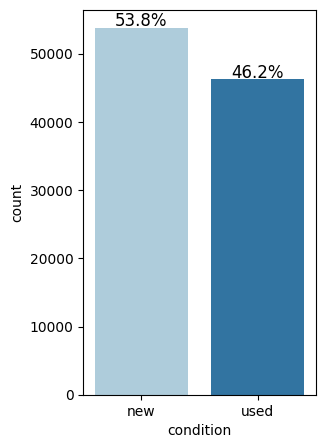

In [ ]:
labeled_barplot(data, 'condition', perc = True, n = None)

El dataset se encuentra balanceado, ya que la variable 'condition' presenta una distribución similar entre las dos categorías:
* 53,8 % de publicaciones “new”
* 46,2 % de publicaciones “used”.

Esta diferencia es pequeña y no representa un desbalance significativo. Por lo tanto, el modelo no se verá sesgado hacia una clase en particular y no es necesario aplicar técnicas de rebalanceo como oversampling o undersampling.

In [ ]:
# Eliminamos la variable 'condition' y nos quedamos con 'condition_bin'
data.drop('condition', axis=1, inplace=True)

###**Análisis Univariado**

#### **Numéricas**

In [ ]:
# Función vista en Guided project MIT (Guided Project - Making Sense of Unstructured Data (OPTIONAL)

def histogram_boxplot(data, feature, figsize = (12, 7), kde = False, bins = None):

    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12, 7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows = 2,      # Number of rows of the subplot grid = 2
        sharex = True,  # X-axis will be shared among all subplots
        gridspec_kw = {"height_ratios": (0.25, 0.75)},
        figsize = figsize,
    )  # Creating the 2 subplots
    sns.boxplot(
        data = data, x = feature, ax = ax_box2, showmeans = True, color = "violet"
    )  # Boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2, bins = bins, palette = "winter"
    ) if bins else sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color = "green", linestyle = "--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color = "black", linestyle = "-"
    )  # Add median to the histogram

Dado que al intentar hacer el histograma nos quedamos sin memoria RAM en Colab,
porque el dataset original tiene 100.000 observaciones; vamos a realizar un muestreo aleatorio del 10 % (10.000 observaciones).
Esto nos va permitir trabajar con una muestra representativa, manteniendo la misma distribución de las variables, pero reduciendo el uso de memoria y mejorando la velocidad de procesamiento.

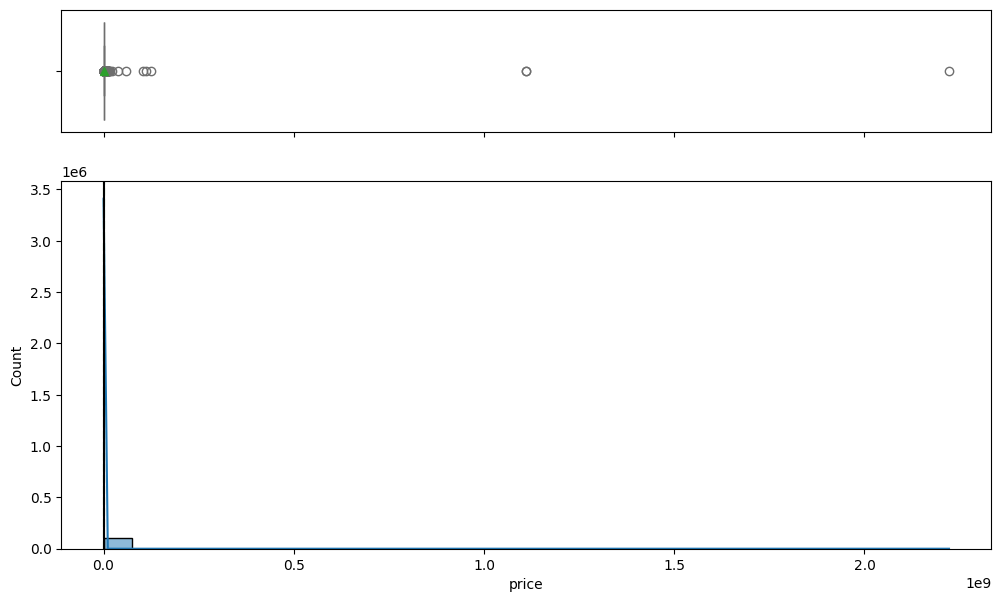

In [ ]:
histogram_boxplot(data, 'price', kde = True, bins = 30);

Aplicamos la transformación logarítmica a la variable price porque su distribución está muy sesgada a la derecha, la mayoría de los productos tienen precios bajos, pero hay algunos con valores extremadamente altos que distorsionan los gráficos y el análisis.

Con log(1 + price) comprimimos esos valores grandes, obteniendo una distribución más equilibrada, fácil de visualizar y más adecuada para los modelos estadísticos o de machine learning.

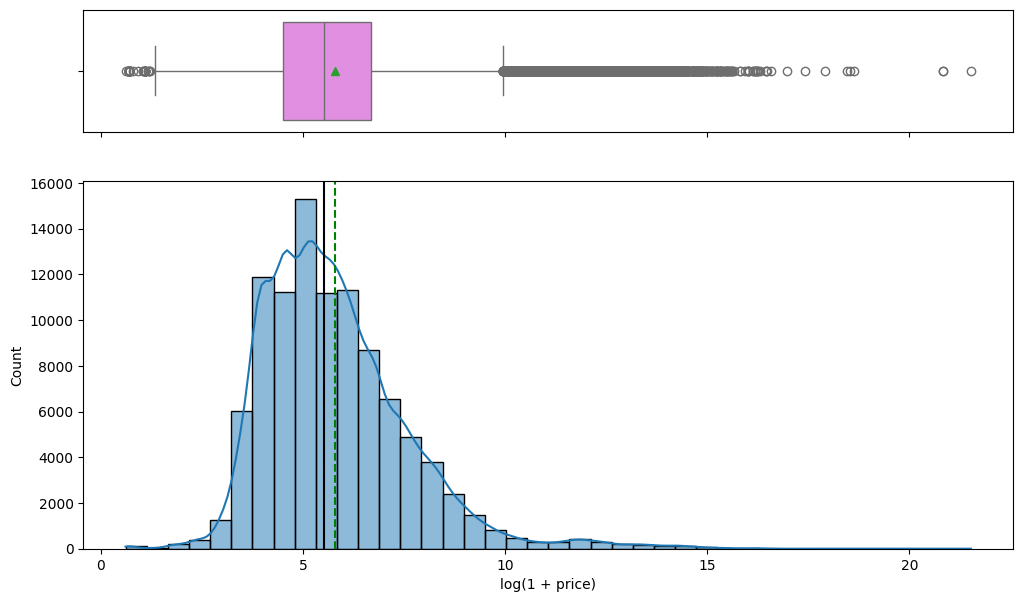

In [ ]:
data['price_log'] = np.log1p(data['price'])

histogram_boxplot(data, 'price_log', kde = True, bins = 40);
plt.xlabel('log(1 + price)')
plt.show()

El histograma muestra que la mayoría de los precios se concentran en valores bajos, mientras que hay pocos productos con precios muy altos (cola derecha larga). Esto indica que la variable 'price' está fuertemente sesgada hacia la derecha.

El boxplot confirma la presencia de outliers extremos, representados por los puntos alejados a la derecha, que elevan la media por encima de la mediana.

En conjunto, ambos gráficos evidencian que el precio tiene una alta dispersión y algunos valores fuera de rango que podrían afectar el análisis o los modelos, motivo por el cual luego aplicamos la transformación logarítmica.

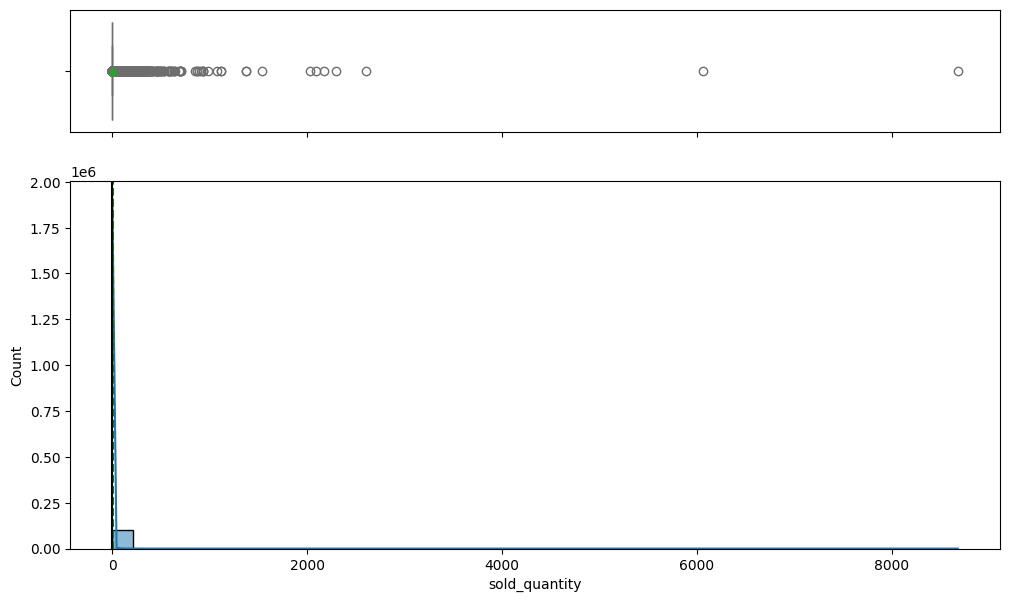

In [ ]:
histogram_boxplot(data, 'sold_quantity', kde = True, bins = 40)

Vamos a aplicarle log también, por las mismas razones que en los casos anteriores.
Con log(1 + price) comprimimos esos valores más grandes, obteniendo una distribución más equilibrada, fácil de visualizar y más adecuada para los modelos estadísticos o de machine learning.

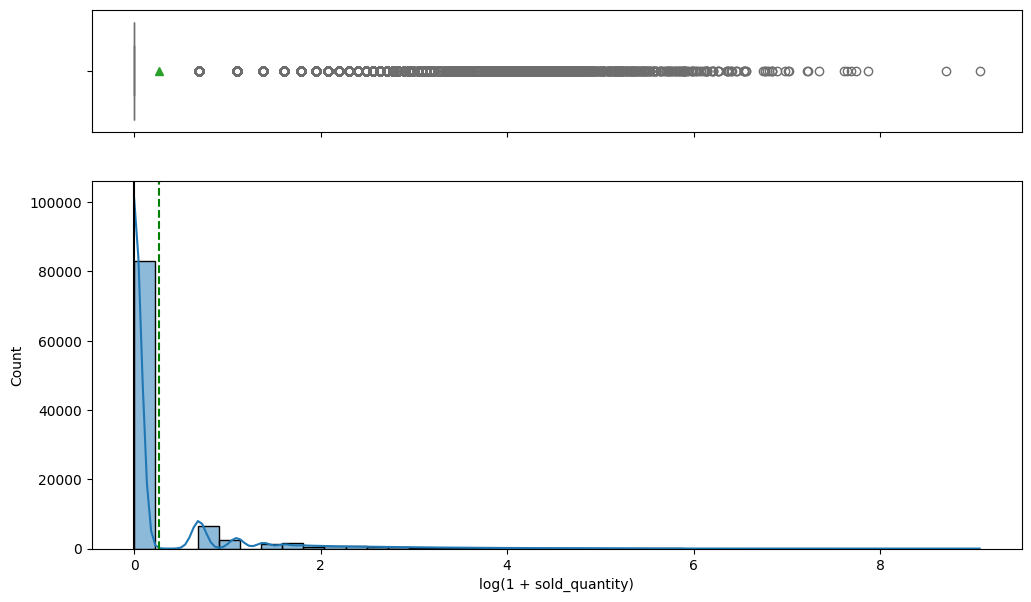

In [ ]:
data['sold_quantity_log'] = np.log1p(data['sold_quantity'])

histogram_boxplot(data, 'sold_quantity_log', kde = True, bins = 40);
plt.xlabel('log(1 + sold_quantity)')
plt.show()

La mayoría de los artículos publicados no registran ventas o tienen ventas bajas, mientras que un pequeño grupo alcanza volúmenes muy altos.
Esto sugiere una distribución desigual del éxito de las publicaciones, donde pocas publicaciones concentran la mayoría de las ventas.

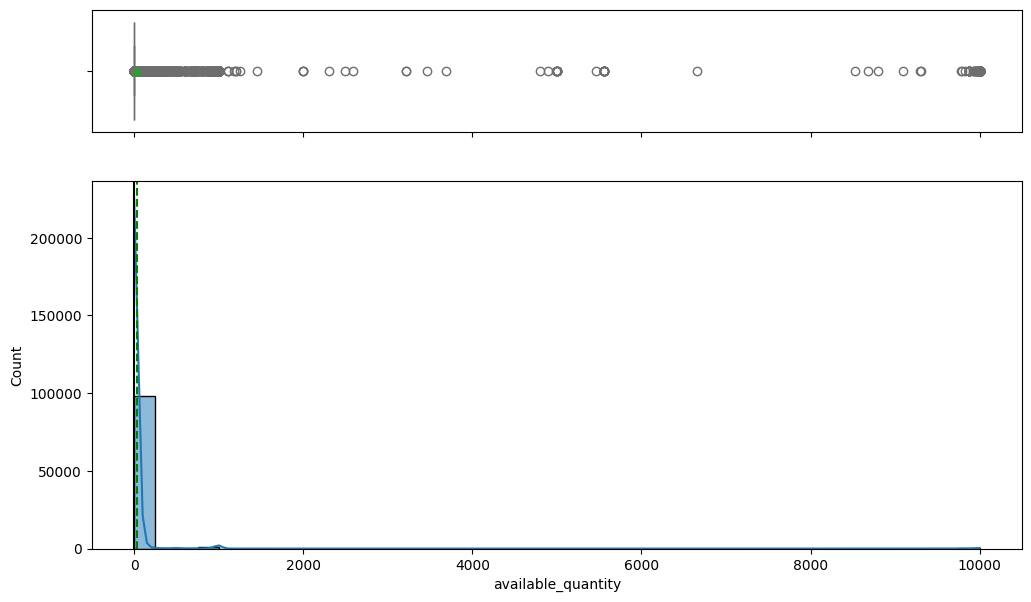

In [ ]:
histogram_boxplot(data, 'available_quantity', kde = True, bins = 40)

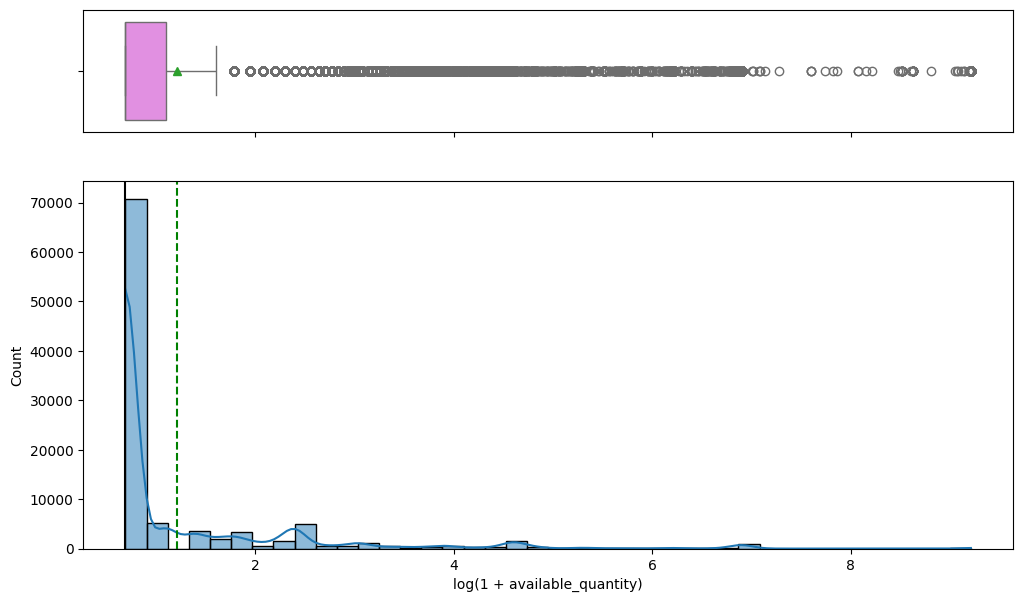

In [ ]:
data['available_quantity_log'] = np.log1p(data['available_quantity'])

histogram_boxplot(data, 'available_quantity_log', kde = True, bins = 40);
plt.xlabel('log(1 + available_quantity)')
plt.show()


La mayoría de las publicaciones tienen una baja cantidad disponible (pocas unidades en stock), concentrándose en valores cercanos a 0.
A medida que la cantidad disponible aumenta, las observaciones se vuelven menos frecuentes.

La variable 'available_quantity' presenta una alta concentración de valores bajos y algunos casos extremos de stock muy elevado.
Esto sugiere que la mayoría de los vendedores publican pocos productos, mientras que unos pocos manejan grandes volúmenes.

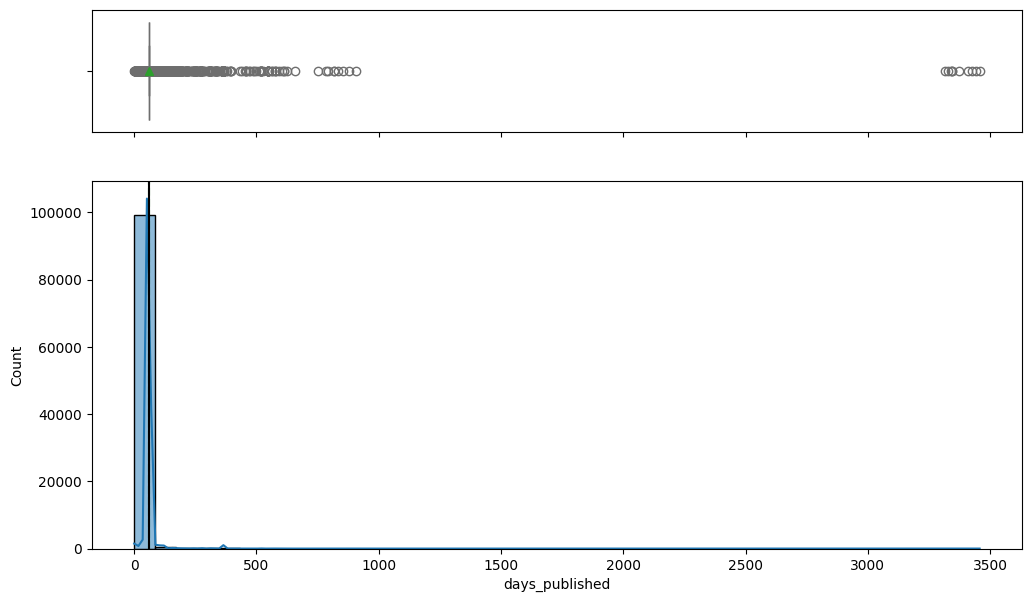

In [ ]:
histogram_boxplot(data, 'days_published', kde = True, bins = 40)

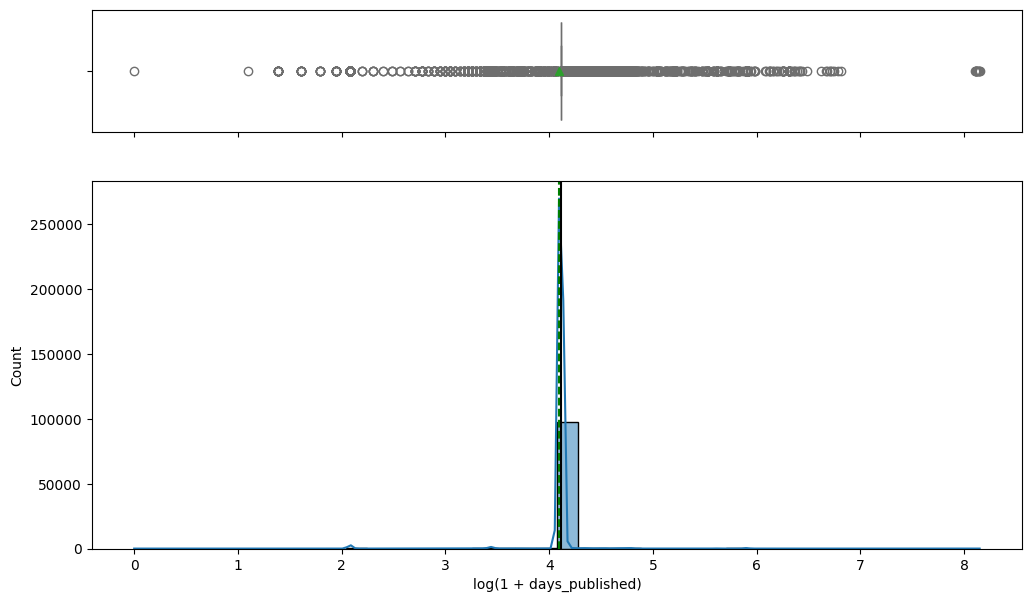

In [ ]:
data['days_published_log'] = np.log1p(data['days_published'])

histogram_boxplot(data, 'days_published_log', kde = True, bins = 40);
plt.xlabel('log(1 + days_published)')
plt.show()

La mayoría de las publicaciones tienen una antigüedad relativamente baja, con la mayor concentración entre 30 y 60 días publicados.
Después de aplicar la transformación logarítmica, se observa una distribución más concentrada y menos afectada por los pocos casos que llevan muchos días activos (hasta 800).

La variable days_published muestra que la mayoría de los productos se publican y se renuevan dentro de plazos cortos, aunque existen algunos outliers con tiempos de publicación inusualmente largos.

#### **Categóricas**

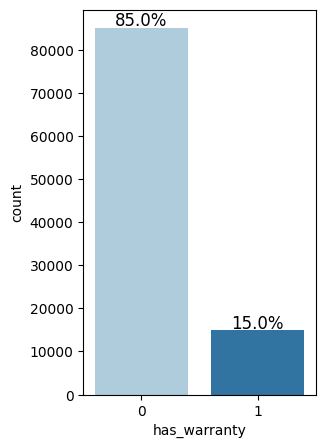

In [ ]:
labeled_barplot(data, 'has_warranty', perc = True, n = None)

La variable 'has_warranty' indica si el producto cuenta con garantía.
Se observa que el 85 % de las publicaciones no incluyen garantía, mientras que el 15 % sí.
Esto muestra que la mayoría de los productos ofrecidos en marketplace de Mercado Libre Argentina no disponen de una garantía explícita.

In [ ]:
# Eliminamos la variable 'warranty_months' ya que vamos a seguir en adelante con la binaria 'has_warranty'
data.drop('warranty_months', axis=1, inplace=True)

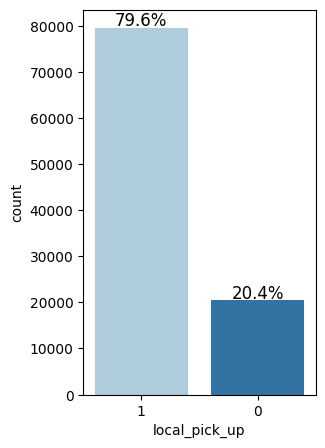

In [ ]:
labeled_barplot(data, 'local_pick_up', perc = True, n = None)

Podemos ver que el 79% de las publicaciones sí ofrecen retiro en el local (1) y el 21% no ofrecen esta opción (0).

Esto refleja que la gran mayoría de los vendedores permiten al comprador retirar el producto en persona, probablemente porque reduce costos de envío y agiliza la entrega.
El 21% restante depende exclusivamente de envíos, lo que podría estar vinculado a vendedores de otras regiones o a productos más grandes o delicados.

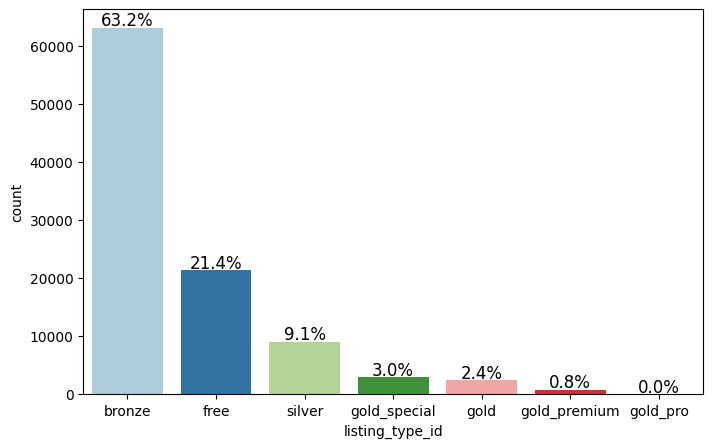

In [ ]:
labeled_barplot(data, 'listing_type_id', perc = True, n = None)


Podemos ver que el 63.2 % de las publicaciones pertenecen a la categoría bronze, seguidas por un 21.4 % de la categoría free, un 9.1 % de la categoría silver, un 3.0 % de la categoría gold_special, un 2.4 % de gold y un 0.8 % de gold_premium.

Esto demuestra que la mayoría de los vendedores en el dataset se concentran en planes de bajo costo (bronze y free llegan al 84%), que en conjunto representan más del 80 % del total de publicaciones.
Los planes premium o profesionales son poco comunes, lo que sugiere que el público de esta muestra está compuesto principalmente por vendedores pequeños o medianos, más que por grandes marcas o empresas consolidadas.

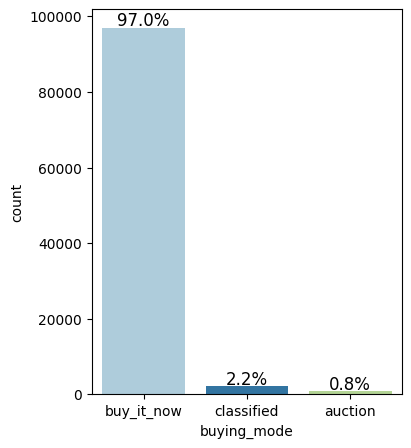

In [ ]:
labeled_barplot(data, 'buying_mode', perc = True, n = None)

El 97 % de las publicaciones corresponden al modo 'buy_it_now', mientras que solo un 2.2 % son del tipo 'classified' y un 0.8% pertenecen al formato 'auction'.

Esto indica que casi todas las transacciones se realizan a precio fijo e inmediato, sin negociación ni subasta. Los modos alternativos (subasta o clasificado) tienen una presencia mínima, lo que refleja que los usuarios de la plataforma prefieren operaciones rápidas y directas, en lugar de procesos más largos o inciertos como las subastas.

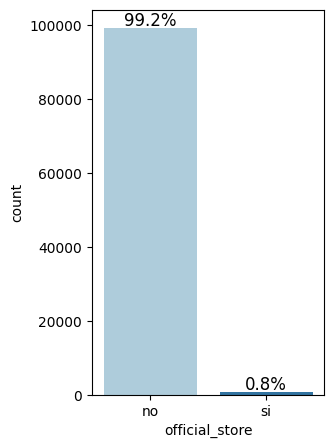

In [ ]:
labeled_barplot(data, 'official_store', perc = True, n = None)

La variable 'official_store' indica si la publicación pertenece a una tienda oficial. Se observa que el 99,2 % de los productos no provienen de tiendas oficiales, mientras que solo el 0,8 % sí lo hacen.
Esto refleja que la gran mayoría de las publicaciones en el marketplace corresponden a vendedores independientes.

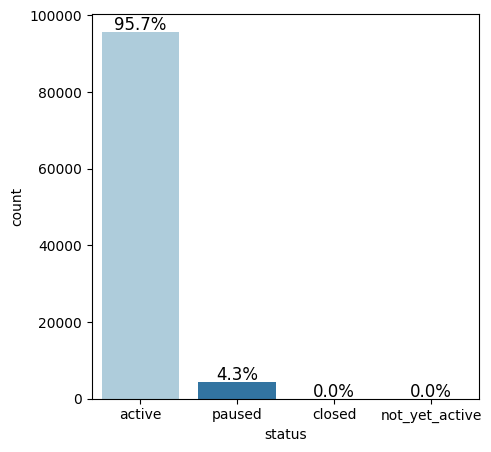

In [ ]:
labeled_barplot(data, 'status', perc = True, n = None)

El 95.7 % de las publicaciones se encuentran activas, mientras que un 4.3 % están pausadas y prácticamente ninguna aparece como cerrada.

Esto indica que la gran mayoría de los productos están actualmente disponibles para la venta, reflejando una alta actividad comercial en la plataforma y una baja rotación o finalización de publicaciones.

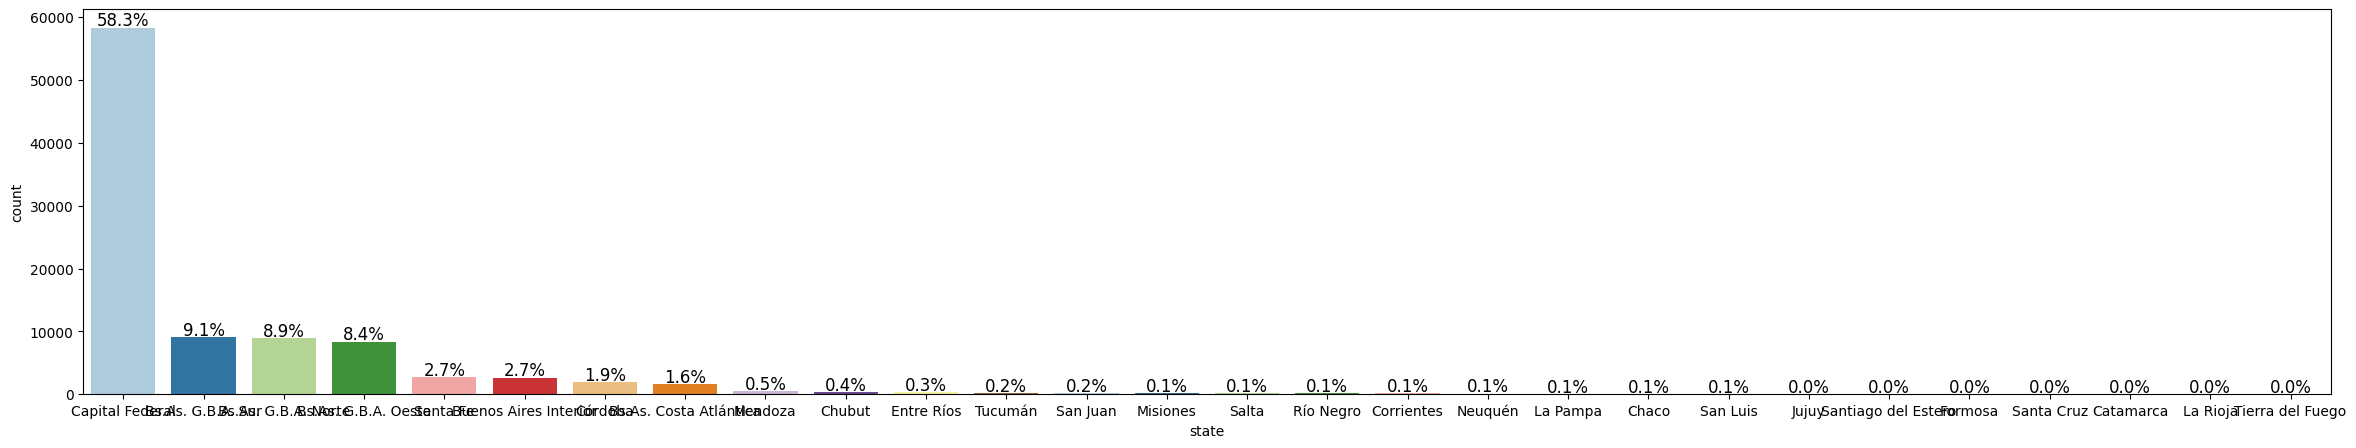

In [ ]:
labeled_barplot(data, 'state', perc = True, n = None)

La variable 'state'presenta muchas categorías, por lo que optamos por mostrarla en formato horizontal para facilitar la visualización y comparación entre provincias.

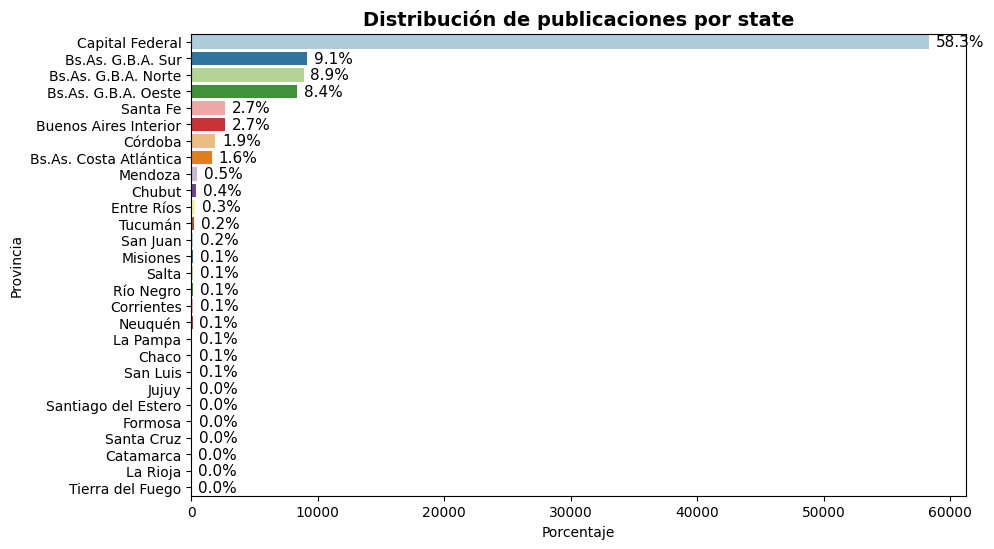

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=data,
    y='state',
    palette='Paired',
    order=data['state'].value_counts().index  # ordenado de mayor a menor
)

total = len(data['state'])

# Agregamos etiquetas de porcentaje
for p in ax.patches:
    label = "{:.1f}%".format(100 * p.get_width() / total)
    y = p.get_y() + p.get_height() / 2
    x = p.get_width()
    ax.annotate(
        label,
        (x, y),
        ha='left',
        va='center',
        size=11,
        xytext=(5, 0),
        textcoords='offset points'
    )

plt.xlabel("Porcentaje")
plt.ylabel("Provincia")
plt.title("Distribución de publicaciones por state", fontsize=14, weight='bold')
plt.show()


Unificamos las distintas zonas del Gran Buenos Aires bajo la categoría 'Gran Buenos Aires'.
Aclaramos que 'Capital Federal' corresponde a la Ciudad Autónoma de Buenos Aires (CABA) y no es lo mismo que la provincia de Buenos Aires.
La provincia de Buenos Aires rodea a la Capital Federal, pero son jurisdicciones distintas, por lo que mantenemos separadas las categorías 'Capital Federal' y 'Gran Buenos Aires'.

In [ ]:
# Unificamos las distintas zonas del Gran Buenos Aires bajo la provincia 'Buenos Aires'
data['state'] = data['state'].replace({
    'Bs.As. G.B.A. Norte': 'Gran Buenos Aires',
    'Bs.As. G.B.A. Sur': 'Gran Buenos Aires',
    'Bs.As. G.B.A. Oeste': 'Gran Buenos Aires',
    'Buenos Aires Interior': 'Gran Buenos Aires',
    'Bs.As. Costa Atlántica': 'Gran Buenos Aires'
})


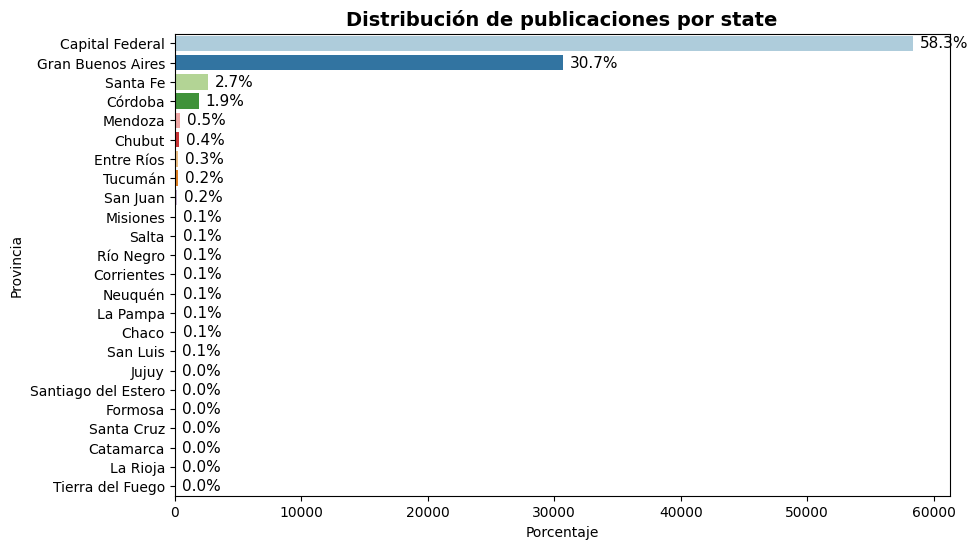

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=data,
    y='state',
    palette='Paired',
    order=data['state'].value_counts().index  # ordenado de mayor a menor
)

total = len(data['state'])

# Agregamos etiquetas de porcentaje
for p in ax.patches:
    label = "{:.1f}%".format(100 * p.get_width() / total)
    y = p.get_y() + p.get_height() / 2
    x = p.get_width()
    ax.annotate(
        label,
        (x, y),
        ha='left',
        va='center',
        size=11,
        xytext=(5, 0),
        textcoords='offset points'
    )

plt.xlabel("Porcentaje")
plt.ylabel("Provincia")
plt.title("Distribución de publicaciones por state", fontsize=14, weight='bold')
plt.show()

Podemos observar que sólo cuatro provincias concentran más del 93% de las publicaciones.
Además, más del 89 % del total se encuentra en Capital Federal (58.3 %) y Gran Buenos Aires (30.7 %), lo que evidencia una fuerte concentración de actividad en el área metropolitana.
El resto de las publicaciones se distribuye principalmente entre Santa Fe (2.7 %) y Córdoba (1.9 %), mientras que las demás provincias tienen una participación mínima.

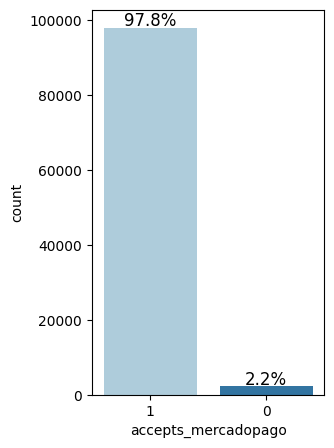

In [ ]:
labeled_barplot(data, 'accepts_mercadopago', perc = True, n = None)

La variable 'accepts_mercadopago' indica si la publicación acepta o no mercadopago como medio de pago (1 = sí, 0 = no). En el gráfico se observa que el 97,8 % de los productos sí aceptan, mientras que solo el 2,2 % no lo aceptan, por lo que la gran mayoría de las publicaciones ofrece esta forma de pago.

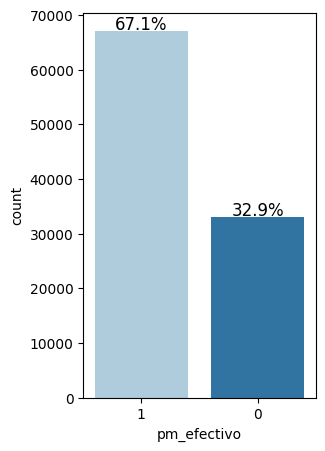

In [ ]:
labeled_barplot(data, 'pm_efectivo', perc = True, n = None)

La variable 'pm_efectivo' indica si la publicación acepta efectivo como medio de pago (1 = sí, 0 = no). Se observa que el 67,1 % de los productos acepta efectivo, mientras que el 32,9 % no lo hace. Es decir, el pago en efectivo es una forma de pago bastante frecuente entre las publicaciones analizadas.

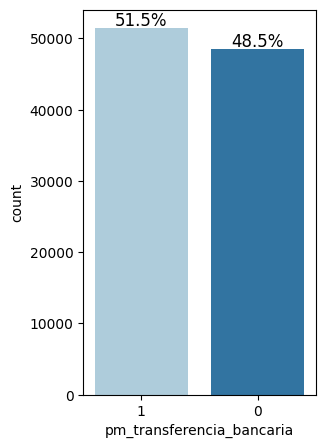

In [ ]:
labeled_barplot(data, 'pm_transferencia_bancaria', perc = True, n = None)

La variable 'pm_transferencia_bancaria' señala si el vendedor permite pagar mediante transferencia bancaria. Aproximadamente el 51,5 % de las publicaciones acepta este método, y el 48,5 % no lo ofrece. La distribución está bastante equilibrada, por lo que la transferencia bancaria aparece como una alternativa relativamente común pero no universal.

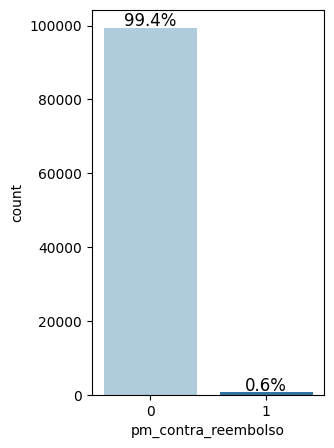

In [ ]:
labeled_barplot(data, 'pm_contra_reembolso', perc = True, n = None)

La variable 'pm_contra_reembolso' indica si la publicación admite el pago contra reembolso. Solo alrededor del 0,6 % de los productos ofrece esta modalidad, mientras que el 99,4 % no la acepta. Esto muestra que el pago contra reembolso es un método muy poco utilizado en este marketplace.

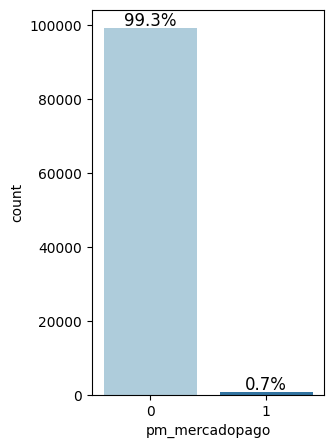

In [ ]:
labeled_barplot(data, 'pm_mercadopago', perc = True, n = None)

La variable 'pm_mercadopago' refleja si, dentro de los métodos de pago alternativos, se incluye mercadopago como opción (1 = sí, 0 = no). En este caso, apenas el 0,7 % de las publicaciones presenta esta forma de pago en este grupo, mientras que el 99,3 % no la tiene marcada, por lo que su presencia en esta categoría específica es residual.

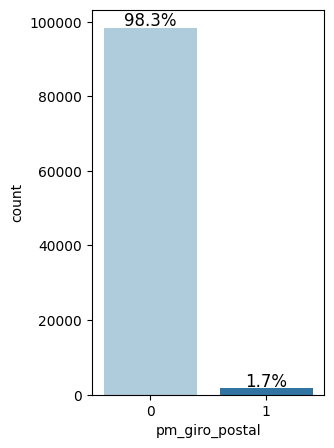

In [ ]:
labeled_barplot(data, 'pm_giro_postal', perc = True, n = None)

La variable 'pm_giro_postal' indica si el vendedor acepta giro postal como medio de pago. Solo el 1,7 % de las publicaciones ofrece esta opción, frente a un 98,3 % que no la admite, lo que la convierte también en una forma de pago poco frecuente.

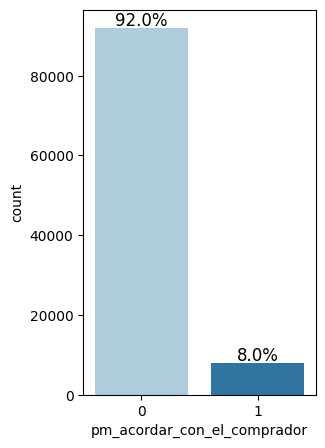

In [ ]:
labeled_barplot(data, 'pm_acordar_con_el_comprador', perc = True, n = None)

La variable 'pm_acordar_con_el_comprador' señala si el método de pago se deja abierto a “acordar con el comprador”. El 8,0 % de las publicaciones utiliza esta modalidad flexible, mientras que el 92,0 % no lo hace. Es una opción minoritaria, pero más habitual que otros métodos poco usados como contra reembolso o giro postal.

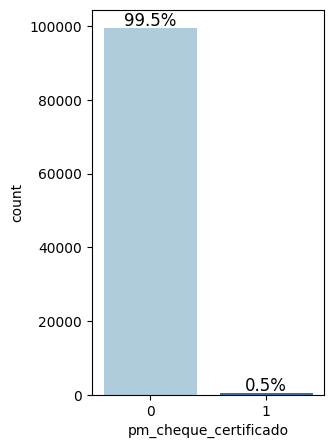

In [ ]:
labeled_barplot(data, 'pm_cheque_certificado', perc = True, n = None)

La variable 'pm_cheque_certificado; indica si se acepta cheque certificado como forma de pago. Solo el 0,5 % de las publicaciones lo admite, en contraste con el 99,5 % que no lo hace, por lo que se trata de un método prácticamente marginal en el conjunto de datos.

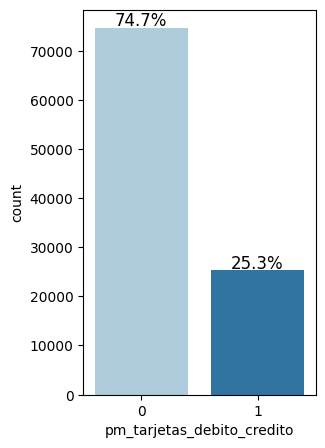

In [ ]:
labeled_barplot(data, 'pm_tarjetas_debito_credito', perc = True, n = None)

La variable 'pm_tarjetas_debito_credito' agrupa los métodos de pago con tarjeta de crédito o débito (Visa, Mastercard, American Express, etc.) e indica si la publicación acepta al menos uno de ellos (1 = sí, 0 = no). En el gráfico se observa que aproximadamente el 25,3 % de los productos permite pagar con tarjeta, mientras que el 74,7 % no ofrece esta opción. Esto muestra que, dentro de los métodos no mercadopago considerados, el uso de tarjetas es relativamente minoritario en comparación con otras formas de pago como efectivo o transferencia bancaria.

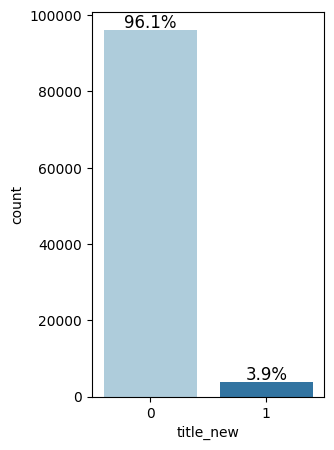

In [ ]:
labeled_barplot(data, 'title_new', perc = True, n = None)

La variable 'title_new' toma valor 1 cuando en el título de la publicación aparece alguna palabra asociada a que el producto es nuevo (por ejemplo, “nuevo”, “a estrenar”, “sin uso”, etc.). Se observa que solo el 3,9 % de los títulos contiene este tipo de indicación explícita, mientras que el 96,1 % no menciona directamente que el artículo sea nuevo. Esto sugiere que, en la mayoría de los casos, la condición del producto no se destaca de forma textual en el título.

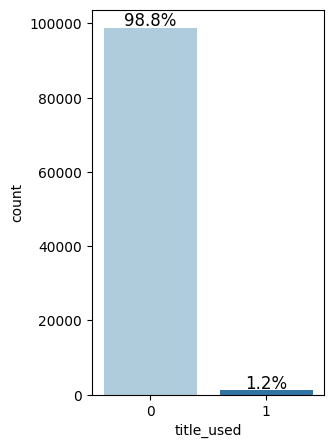

In [ ]:
labeled_barplot(data, 'title_used', perc = True, n = None)

La variable 'title_used' vale 1 cuando el título incluye términos asociados a un producto usado (como “usado”, “seminuevo”, “poco uso”, etc.). En el gráfico se ve que apenas el 1,2 % de las publicaciones menciona explícitamente que el artículo es usado, frente a un 98,8 % que no lo hace. Es decir, es poco común que el vendedor indique de forma clara en el título que el producto ya tuvo uso previo.

### **Análisis Bivariado**

In [ ]:
# Creamos una copia del dataset y sacamos las variables sin log para hacer la matriz de correlación.
data_log = data.drop(['price', 'sold_quantity', 'available_quantity', 'days_published'], axis=1)


In [ ]:
data_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   seller_id                    100000 non-null  int64  
 1   listing_type_id              100000 non-null  object 
 2   buying_mode                  100000 non-null  object 
 3   official_store               100000 non-null  object 
 4   accepts_mercadopago          100000 non-null  int64  
 5   status                       100000 non-null  object 
 6   pm_efectivo                  100000 non-null  int64  
 7   pm_giro_postal               100000 non-null  int64  
 8   pm_mercadopago               100000 non-null  int64  
 9   pm_cheque_certificado        100000 non-null  int64  
 10  pm_transferencia_bancaria    100000 non-null  int64  
 11  pm_acordar_con_el_comprador  100000 non-null  int64  
 12  pm_contra_reembolso          100000 non-null  int64  
 13  

In [ ]:
# En el dataset_sample y sacamos las variables con log.
data_sinlog = data.drop(['price_log', 'sold_quantity_log', 'available_quantity_log', 'days_published_log'], axis=1)

In [ ]:
data_sinlog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   seller_id                    100000 non-null  int64  
 1   listing_type_id              100000 non-null  object 
 2   price                        100000 non-null  float64
 3   buying_mode                  100000 non-null  object 
 4   official_store               100000 non-null  object 
 5   accepts_mercadopago          100000 non-null  int64  
 6   status                       100000 non-null  object 
 7   sold_quantity                100000 non-null  int64  
 8   available_quantity           100000 non-null  int64  
 9   pm_efectivo                  100000 non-null  int64  
 10  pm_giro_postal               100000 non-null  int64  
 11  pm_mercadopago               100000 non-null  int64  
 12  pm_cheque_certificado        100000 non-null  int64  
 13  

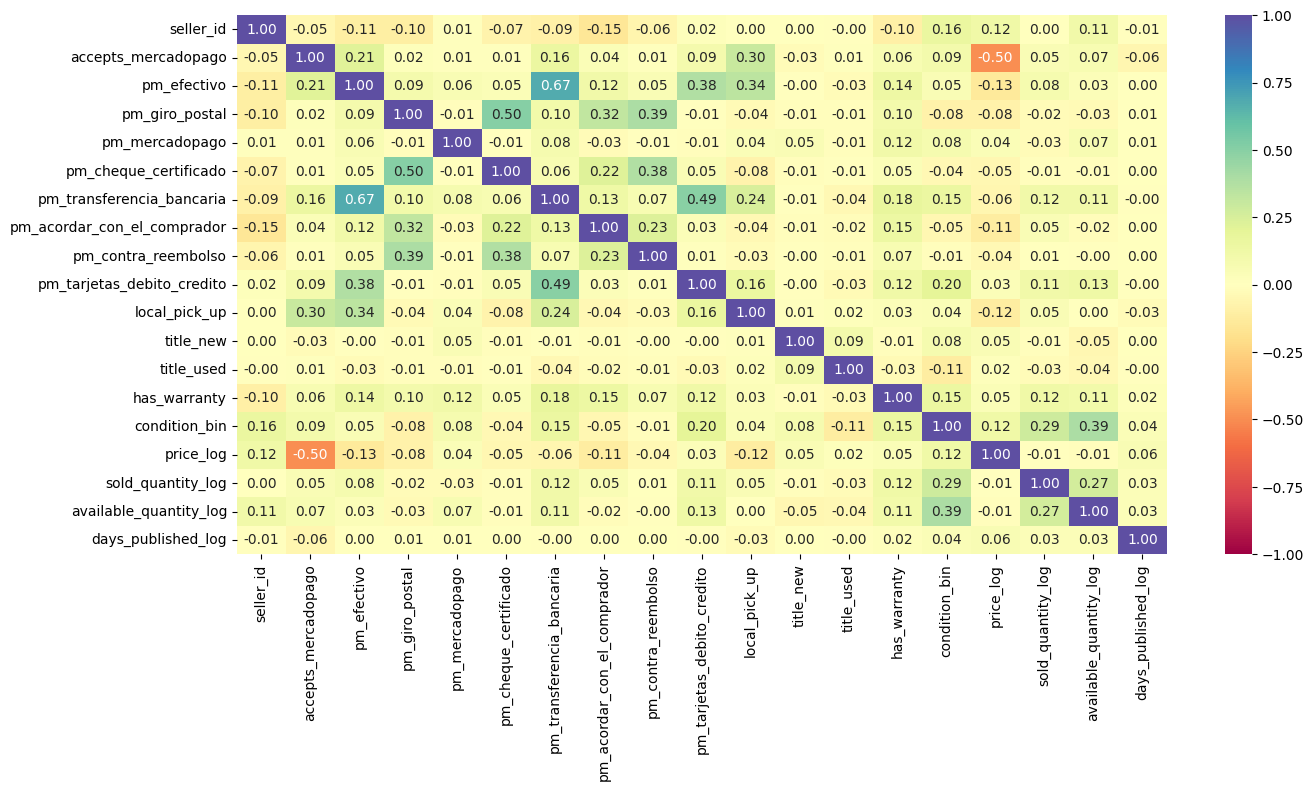

In [ ]:
# Vemos las correlaciones entre las variables numéricas
cols_list = data_log.select_dtypes(include = np.number).columns.tolist()

plt.figure(figsize = (15, 7))

sns.heatmap(
    data_log[cols_list].corr(numeric_only = True), annot = True, vmin = -1, vmax = 1, fmt = ".2f", cmap = "Spectral"
)

plt.show()

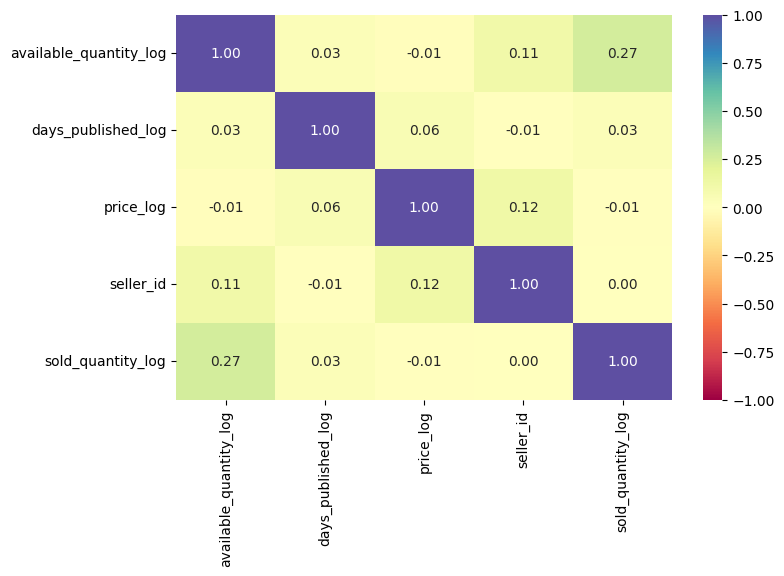

In [ ]:
# Numéricas que en realidad son categóricas
cat_num_cols = [
    'accepts_mercadopago',
    'pm_giro_postal',
    'pm_contra_reembolso',
    'pm_cheque_certificado',
    'pm_transferencia_bancaria',
    'pm_mercadopago',
    'pm_efectivo',
    'pm_acordar_con_el_comprador',
    'pm_tarjetas_debito_credito',
    'local_pick_up',
    'title_new',
    'title_used',
    'has_warranty',
    'condition_bin'
]

# Numéricas continuas que queremos para la correlación
num_real_cols = (
    data_log.select_dtypes(include=np.number)
            .columns
            .difference(cat_num_cols)
    .tolist()
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    data_log[num_real_cols].corr(numeric_only=True),
    annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()



Podemos observar que no existen relaciones fuertes entre las variables, los coeficientes son en general muy bajos, cercanos a 0.
Lo cual nos indica que las variables son en gran medida independientes entre sí, lo que es positivo para evitar problemas de multicolinealidad en los modelos.

La correlación más destacada (aunque baja) se da entre 'sold_quantity_log' y 'available_quantity_log' (27%), lo que sugiere una leve relación de que a mayor cantidad disponible, tiende a haber un poco más de ventas.

También se observa una correlación moderada entre 'price_log' y 'seller_id' (12%), posiblemente porque algunos vendedores manejan rangos de precios específicos.

Las demás correlaciones son prácticamente nulas, lo que confirma que no hay dependencia lineal relevante entre las variables.


#### **Numericas vs Variable Objetivo**

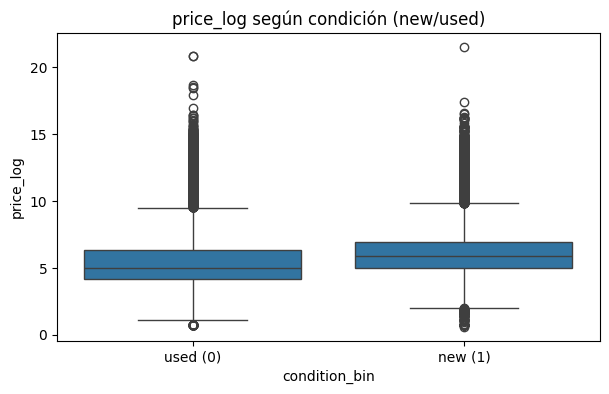

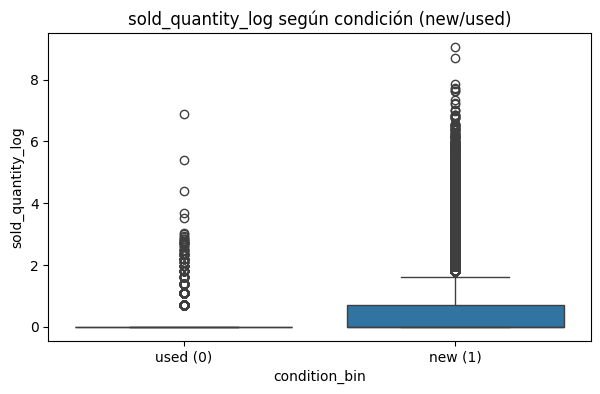

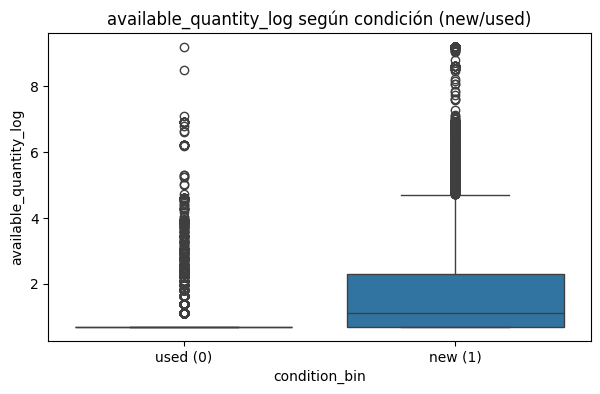

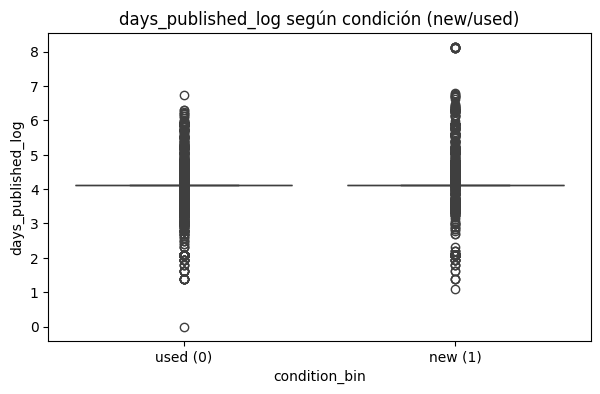

In [ ]:
vars_num = ['price_log', 'sold_quantity_log', 'available_quantity_log', 'days_published_log']

for col in vars_num:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=data_log, x='condition_bin', y=col)
    plt.xticks([0,1], ['used (0)', 'new (1)'])
    plt.title(f'{col} según condición (new/used)')
    plt.show()


1) En el boxplot de price_log se observa que los productos nuevos (condition_bin = 1) tienden a tener precios más altos (en escala logarítmica) que los usados (condition_bin = 0). La mediana de price_log es mayor para los nuevos y también presentan una mayor dispersión y más valores extremos. Esto sugiere que, en general, las publicaciones de productos nuevos se ubican en rangos de precio superiores a las de productos usados.

2) Para sold_quantity_log, la mayoría de los productos usados se concentra cerca de valores muy bajos (muchas publicaciones sin ventas o con pocas ventas), mientras que los nuevos muestran una mediana más alta y una cola superior más larga. Es decir, los artículos nuevos tienden a registrar más unidades vendidas que los usados, lo que podría indicar una mayor demanda o rotación de este tipo de publicaciones.

3) En el caso de available_quantity_log, los productos nuevos presentan una mediana claramente superior y una mayor dispersión respecto a los usados. Esto indica que las publicaciones de artículos nuevos suelen manejar mayores niveles de stock disponible, mientras que los usados, en general, se ofrecen en cantidades mucho más reducidas.

4) Para days_published_log, las distribuciones de nuevos y usados son bastante similares, en términos de tiempo publicado (en escala logarítmica), no se observan diferencias marcadas entre productos nuevos y usados, lo que sugiere que la antigüedad de la publicación no distingue claramente entre ambas condiciones.

#### **Categoricas vs Variable Objetivo**

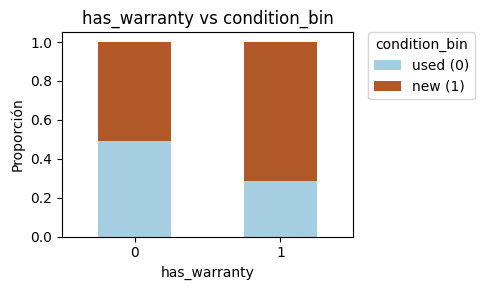

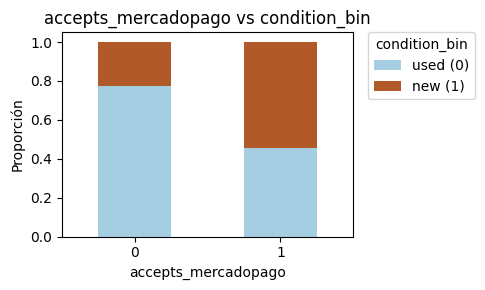

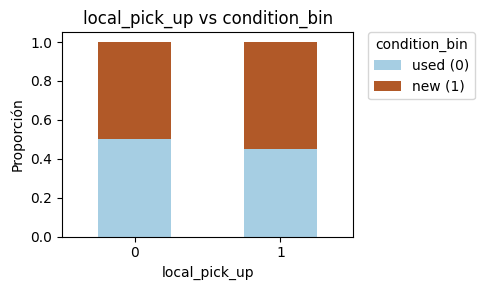

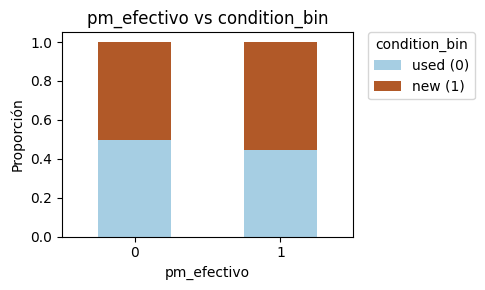

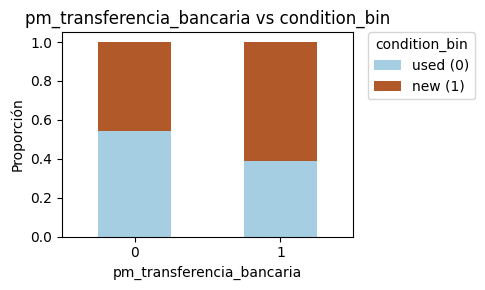

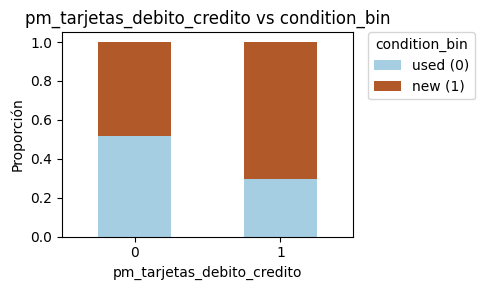

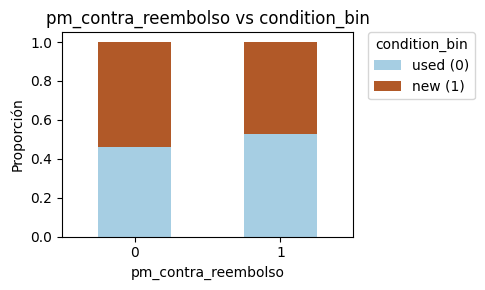

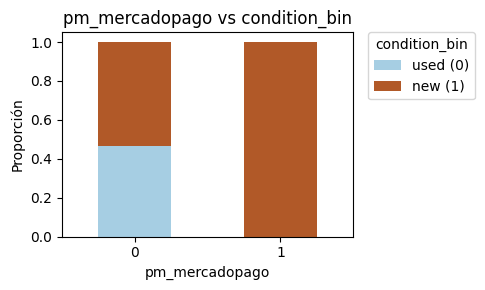

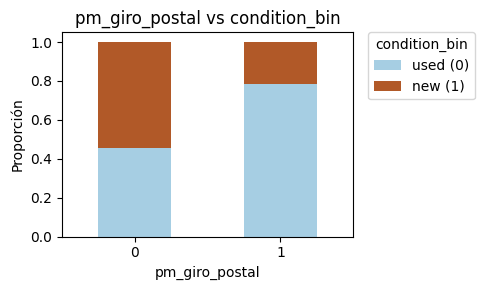

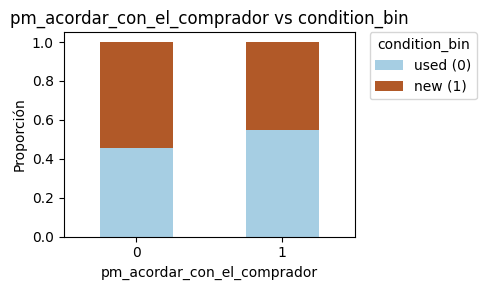

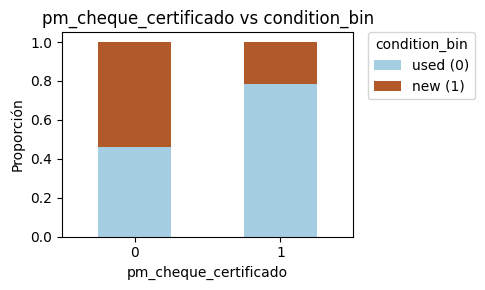

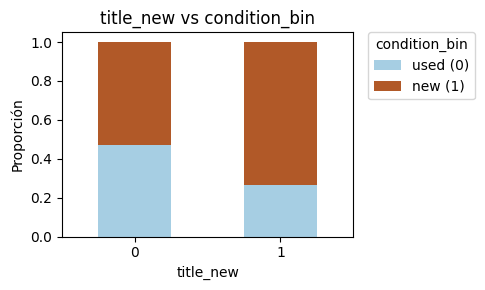

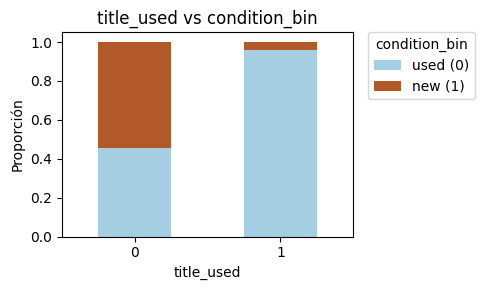

In [ ]:
categoricas = [
    'has_warranty',
    'accepts_mercadopago',
    'local_pick_up',
    'pm_efectivo',
    'pm_transferencia_bancaria',
    'pm_tarjetas_debito_credito',
    'pm_contra_reembolso',
    'pm_mercadopago',
    'pm_giro_postal',
    'pm_acordar_con_el_comprador',
    'pm_cheque_certificado',
    'title_new',
    'title_used'
]

for col in categoricas:
    ct = pd.crosstab(data_log[col], data_log['condition_bin'], normalize='index')

    ax = ct.plot(
        kind='bar',
        stacked=True,
        figsize=(5, 3),
        colormap='Paired'
    )

    plt.title(f'{col} vs condition_bin')
    plt.xlabel(col)
    plt.ylabel('Proporción')
    plt.xticks(rotation=0)

    # 👇 Leyenda fuera del gráfico
    plt.legend(
        title='condition_bin',
        labels=['used (0)', 'new (1)'],
        bbox_to_anchor=(1.05, 1),   # a la derecha
        loc='upper left',
        borderaxespad=0.
    )

    plt.tight_layout()
    plt.show()




1) La variable has_warranty muestra que, tanto entre las publicaciones con como sin garantía, predominan los productos nuevos. Sin embargo, cuando has_warranty = 1 la proporción de productos new (1) es mayor que cuando has_warranty = 0, lo que indica que la presencia de garantía está más asociada a artículos nuevos que usados.

2) En accepts_mercadopago se observa que, entre las publicaciones que no aceptan Mercado Pago (0), la proporción de usados es más alta. En cambio, cuando accepts_mercadopago = 1 aumenta la participación de productos new (1). Es decir, aceptar Mercado Pago está levemente más ligado a publicaciones de artículos nuevos.

3) Para local_pick_up, las proporciones de productos new y used son relativamente similares tanto en 0 como en 1. Ofrecer o no retiro en el domicilio parece no diferenciar de forma clara entre productos nuevos y usados.

4) En pm_efectivo se aprecia que, cuando el vendedor acepta efectivo (1), la proporción de productos new (1) es algo mayor que en el grupo que no acepta efectivo (0). Aun así, en ambos casos conviven productos nuevos y usados, por lo que el uso de efectivo no es un rasgo exclusivo de ninguno de los dos grupos.

5) En pm_transferencia_bancaria, las publicaciones que aceptan transferencia (1) presentan una proporción algo más alta de productos new que el grupo que no la ofrece (0). La diferencia no es extrema, pero sugiere que la transferencia bancaria es algo más frecuente en artículos nuevos.

6) La variable pm_tarjetas_debito_credito muestra una diferencia más marcada: entre las publicaciones que permiten pagar con tarjeta (1), la proporción de productos new (1) es claramente mayor que entre las que no aceptan tarjetas (0). Esto indica que el uso de tarjetas de débito/crédito está fuertemente asociado a productos nuevos.

7) En pm_contra_reembolso, la mayoría de las observaciones pertenecen a 0, donde la mezcla de nuevos y usados es más equilibrada. Entre las pocas publicaciones que ofrecen contra reembolso (1), la proporción de productos nuevos parece algo mayor, aunque este método es tan poco frecuente que su impacto general es limitado.

8) Para pm_mercadopago se observa un patrón claro: cuando pm_mercadopago = 1, prácticamente todas las publicaciones corresponden a productos new (1). En cambio, cuando vale 0 conviven nuevos y usados. Esto sugiere que ofrecer este método de pago alternativo está casi exclusivamente asociado a artículos nuevos.

9) En pm_giro_postal, las publicaciones que no aceptan giro postal (0) presentan una mayor proporción de productos nuevos. Entre las pocas que sí lo aceptan (1), predominan los artículos used (0), indicando que el giro postal es un método más típico de publicaciones de productos usados.

10) La variable pm_acordar_con_el_comprador indica si el método de pago queda a libre acuerdo entre vendedor y comprador. En el gráfico se observa que, cuando pm_acordar_con_el_comprador = 1, la proporción de productos usados (condition_bin = 0) es mayor que la de nuevos. Cuando vale 0, la distribución entre nuevos y usados es más equilibrada. Esto sugiere que esta modalidad flexible de pago se utiliza con más frecuencia en publicaciones de artículos usados.

11) En pm_cheque_certificado, casi todas las publicaciones se encuentran en 0. Dentro de ese grupo la mezcla de nuevos y usados es más equilibrada, mientras que en el reducido grupo que acepta cheque certificado (1) predominan claramente los productos used (0). Este medio de pago se asocia principalmente a artículos usados.

12) La variable title_new indica si el título menciona explícitamente que el producto es nuevo. Cuando title_new = 0, se observa una mezcla de nuevos y usados, aunque con ligera mayoría de productos new. Sin embargo, cuando title_new = 1, la proporción de artículos new (1) aumenta de forma notable, lo que confirma que las palabras relacionadas con “nuevo/a” en el título son un buen indicador de que el producto efectivamente es nuevo.

13) Por último, en title_used se ve un comportamiento muy marcado: cuando title_used = 1 (el título menciona que es usado, seminuevo, etc.), casi todas las publicaciones corresponden a productos used (0). En title_used = 0 conviven nuevos y usados, pero al activarse esta variable el porcentaje de usados se vuelve dominante. Esto muestra que title_used es un fuerte predictor de que el artículo está usado.

## **Modelado**

### **Pre procesamiento de datos**

In [ ]:
# Hacemos una copiad del dataset que usamos en el EDA bivariado
data_model = data_log.copy()


### **One-hot encoding de las categoricas**

 Antes del modelado, convertimos las variables categóricas en formato numérico mediante One-hot encoding, ya que los modelos como la regresión logística solo pueden procesar números. De esta forma, cada categoría se representa como una columna binaria independiente, lo que evita que el modelo interprete erróneamente una relación de orden entre categorías.

In [ ]:
data_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   seller_id                    100000 non-null  int64  
 1   listing_type_id              100000 non-null  object 
 2   buying_mode                  100000 non-null  object 
 3   official_store               100000 non-null  object 
 4   accepts_mercadopago          100000 non-null  int64  
 5   status                       100000 non-null  object 
 6   pm_efectivo                  100000 non-null  int64  
 7   pm_giro_postal               100000 non-null  int64  
 8   pm_mercadopago               100000 non-null  int64  
 9   pm_cheque_certificado        100000 non-null  int64  
 10  pm_transferencia_bancaria    100000 non-null  int64  
 11  pm_acordar_con_el_comprador  100000 non-null  int64  
 12  pm_contra_reembolso          100000 non-null  int64  
 13  

In [ ]:
# Columnas categóricas (tipo object)
cat_cols = ['listing_type_id', 'buying_mode', 'official_store', 'status', 'state']

# One-hot encoding con drop_first para evitar multicolinealidad perfecta
data_model = pd.get_dummies(data_model, columns=cat_cols, drop_first=True)

data_model.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   seller_id                     100000 non-null  int64  
 1   accepts_mercadopago           100000 non-null  int64  
 2   pm_efectivo                   100000 non-null  int64  
 3   pm_giro_postal                100000 non-null  int64  
 4   pm_mercadopago                100000 non-null  int64  
 5   pm_cheque_certificado         100000 non-null  int64  
 6   pm_transferencia_bancaria     100000 non-null  int64  
 7   pm_acordar_con_el_comprador   100000 non-null  int64  
 8   pm_contra_reembolso           100000 non-null  int64  
 9   pm_tarjetas_debito_credito    100000 non-null  int64  
 10  local_pick_up                 100000 non-null  int64  
 11  title_new                     100000 non-null  int64  
 12  title_used                    100000 non-null

### **Eliminamos columnas que no aportan al modelo**

In [ ]:
# Eliminamos la variable 'seller_id', no paorta al modelo es un identificador
data_model.drop('seller_id', axis=1, inplace=True)

### **Definimos la Variable Objetivo y la features del modelo**

In [ ]:
# Nuestra variable objetivo va a ser 'contidion_bin'
# El resto de las variables van a ser consideradas features para el modelo

# Variable Objetivo
y = data_model['condition_bin']

#Todas las variables menos la target
X = data_model.drop(columns=['condition_bin'])


### **Separar variables numéricas continuas y binarias**

Solamente vamos a escalar las variables numericas continuas,ya que son variables que pueden tomar muchos valores distintos y en rangos diferentes.

In [ ]:
num_cols = ['price_log', 'sold_quantity_log', 'available_quantity_log', 'days_published_log']


### **Separamos el data set en Train y Test**

Aunque el dataset completo esté bastante balanceado (55% new, 45% used), al partirlo al azar puede que que se desbalance.

stratify=y garantiza que train y test tengan aproximadamente la misma proporción de new/used que el dataset original.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y #
    )

### **Escalar variables numericas**

In [ ]:
scaler = StandardScaler()

# Copiamos para no pisar X_train y X_test originales
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Ajustamos el scaler solo con el train
scaler.fit(X_train[num_cols])

# Transformamos las columnas continuas
X_train_scaled[num_cols] = scaler.transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])


### **Definimos una funcion para mostrar los resultados de los 3 modelos**

In [ ]:
def mostrar_resultados(modelo, nombre_modelo, X_te):
    y_pred = modelo.predict(X_te)

    # Métricas globales (macro: promedio entre clases)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec  = recall_score(y_test, y_pred, average='macro')
    f1   = f1_score(y_test, y_pred, average='macro')

    print(f'\n===== {nombre_modelo} =====')
    print("Accuracy:", round(acc, 4))
    print("Precision (macro):", round(prec, 4))
    print("Recall (macro):", round(rec, 4))
    print("F1-score (macro):", round(f1, 4))

    print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification report:\n", classification_report(y_test, y_pred))


* **Accuracy: **mide el porcentaje total de aciertos del modelo. Es la proporción de observaciones correctamente clasificadas (nuevos y usados) sobre el total de observaciones del conjunto de test.

* **Precision:** para una clase dada (por ejemplo, productos nuevos), indica qué porcentaje de las predicciones positivas del modelo son correctas. Es decir, de todos los productos que el modelo predijo como “nuevos”, qué fracción realmente son nuevos.

* **Recall:** para una clase dada, mide qué porcentaje de los casos positivos reales detecta el modelo. Es decir, de todos los productos que son realmente “nuevos”, qué fracción el modelo identifica correctamente como nuevos.

* **F1-score:** es la media armónica entre precision y recall. Resume en un único valor el compromiso entre cuántos positivos predichos son correctos (precision) y cuántos positivos reales se detectan (recall). Valores de F1 cercanos a 1 indican un buen equilibrio entre ambas métricas.

## **Modelo 1 - Regresion Logistica**

La regresión logística es un modelo lineal de clasificación binaria que estima la probabilidad de pertenecer a una de dos clases, en nuestro caso, que una publicación corresponda a un producto nuevo (condition_bin = 1) frente a usado (condition_bin = 0).

El modelo combina las variables explicativas (precio, cantidad vendida, stock disponible, días publicados, métodos de pago, garantía, información del título, etc.) en una función lineal y aplica una función logística para obtener una probabilidad entre 0 y 1.

Es un modelo sencillo, interpretable y sirve como baseline, ya que permite analizar el signo y la importancia relativa de cada variable sobre la probabilidad de que el artículo sea nuevo.

(En este modelo usamos el dataset escalado)

In [ ]:
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train_scaled, y_train)

mostrar_resultados(logreg_model, "Regresión Logística", X_test_scaled)



===== Regresión Logística =====
Accuracy: 0.8318
Precision (macro): 0.831
Recall (macro): 0.8325
F1-score (macro): 0.8314

Matriz de confusión:
 [[11678  2195]
 [ 2850 13277]]

Classification report:
               precision    recall  f1-score   support

           0       0.80      0.84      0.82     13873
           1       0.86      0.82      0.84     16127

    accuracy                           0.83     30000
   macro avg       0.83      0.83      0.83     30000
weighted avg       0.83      0.83      0.83     30000



En la regresión logística, el modelo obtiene un accuracy de 0,8318 (83,2 %) sobre el conjunto de test, es decir, clasifica correctamente algo más de ocho de cada diez publicaciones como nuevas o usadas. Las métricas promedio entre clases también son consistentes: la precision macro es 0,831, el recall macro 0,8325 y el F1-score macro 0,8314, lo que indica un desempeño equilibrado entre ambas clases.

A nivel de cada clase, para los productos usados (0) se obtiene una precision de 0,80, recall de 0,84 y F1 de 0,82, mientras que para los nuevos (1) la precision es 0,86, el recall 0,82 y el F1 de 0,84. Esto significa que, cuando el modelo predice que un producto es nuevo, acierta el 86 % de las veces, y detecta alrededor del 82 % de todos los productos nuevos reales. La matriz de confusión muestra que el modelo confunde a algunos usados como nuevos (2.195 casos) y a algunos nuevos como usados (2.850 casos), pero sin un sesgo extremo hacia una de las clases.

Dado que los valores de accuracy, precision, recall y F1 se sitúan todos en torno al 0,83 y son similares para ambas clases, podemos concluir que la regresión logística logra un rendimiento sólido y bastante balanceado para diferenciar entre publicaciones de productos nuevos y usados.

## **Modelo 2 - Support Vector Machine (SVM)**

El Support Vector Machine(SVM) es un modelo de clasificación que busca encontrar el hiperplano que mejor separa las clases, maximizando el margen entre los ejemplos de una clase y de la otra. Al utilizar un kernel RBF (Radial Basis Function), el modelo puede capturar fronteras de decisión no lineales en el espacio de las variables, lo que resulta útil cuando la separación entre productos nuevos y usados no es lineal. En este trabajo, la SVM con kernel RBF aprovecha tanto las variables numéricas escaladas (precio, ventas, stock, días publicados) como las dummies binarias (garantía, formas de pago, información del título, etc.) para construir una frontera de decisión más flexible y potencialmente más precisa que la regresión logística.

In [ ]:
# El parámetro C controla el grado de penalización por errores de clasificación en el conjunto de entrenamiento:
# valores altos de C producen fronteras más complejas (menor regularización), mientras que valores bajos favorecen modelos más simples y generalizables.

In [ ]:
# El parámetro gamma controla el alcance del kernel RBF (Radial Basis Function):
# valores altos generan fronteras de decisión muy locales y complejas, mientras que valores bajos producen fronteras más suaves.
# En este trabajo se utilizó gamma="scale", que ajusta automáticamente γ según la variabilidad de los predictores.

In [ ]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

svm_model.fit(X_train_scaled, y_train)

mostrar_resultados(svm_model, "SVM (kernel RBF)", X_test_scaled)


===== SVM (kernel RBF) =====
Accuracy: 0.8374
Precision (macro): 0.8367
Recall (macro): 0.8384
F1-score (macro): 0.837

Matriz de confusión:
 [[11814  2059]
 [ 2818 13309]]

Classification report:
               precision    recall  f1-score   support

           0       0.81      0.85      0.83     13873
           1       0.87      0.83      0.85     16127

    accuracy                           0.84     30000
   macro avg       0.84      0.84      0.84     30000
weighted avg       0.84      0.84      0.84     30000



En el modelo SVM con kernel RBF, el accuracy obtenido en el conjunto de test es de 0,8374 (83,7 %), ligeramente superior al de la regresión logística y al del Random Forest. Las métricas promedio entre clases también son altas y muy equilibradas: la precision macro es 0,837, el recall macro 0,838 y el F1-score macro 0,837, lo que indica un buen desempeño global tanto para productos nuevos como usados.

Observando el detalle por clase, para los productos usados (0) la precisión es 0,81, el recall 0,85 y el F1 0,83; es decir, cuando el modelo predice “usado”, acierta en el 81 % de los casos y consigue identificar alrededor del 85 % de los usados reales. Para los productos nuevos (1) se obtiene una precisión de 0,87, un recall de 0,83 y un F1 de 0,85, lo que muestra que la mayoría de las predicciones de “nuevo” son correctas y que el modelo detecta más del 80 % de los nuevos reales.

La matriz de confusión indica que el SVM clasifica correctamente 11.814 productos usados y 13.309 productos nuevos, mientras que confunde 2.059 usados como nuevos y 2.818 nuevos como usados. En comparación con los otros modelos probados, el SVM alcanza los valores más altos de accuracy y F1-macro, por lo que se perfila como el modelo con mejor rendimiento para distinguir entre publicaciones de productos nuevos y usados en este conjunto de datos.

## **Modelo 3 - Random Forest**

Random Forest es un modelo de ensamble basado en la combinación de muchos árboles de decisión entrenados sobre subconjuntos aleatorios de observaciones y de variables. Cada árbol genera una predicción y el bosque toma la decisión final por votación mayoritaria. Esta estrategia reduce el sobreajuste típico de un solo árbol y suele mejorar la capacidad predictiva.

En nuestro problema, Random Forest permite capturar relaciones complejas entre las características de las publicaciones (precio, garantía, métodos de pago, stock, etc.) y la condición del producto (nuevo/usado), manteniendo al mismo tiempo cierta robustez frente a outliers y ruido. Además, el modelo proporciona medidas de importancia de variables, que ayudan a identificar qué factores son más relevantes para distinguir entre productos nuevos y usados.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

mostrar_resultados(rf_model, "Random Forest", X_test_scaled)


===== Random Forest =====
Accuracy: 0.8325
Precision (macro): 0.832
Recall (macro): 0.8338
F1-score (macro): 0.8321

Matriz de confusión:
 [[11801  2072]
 [ 2953 13174]]

Classification report:
               precision    recall  f1-score   support

           0       0.80      0.85      0.82     13873
           1       0.86      0.82      0.84     16127

    accuracy                           0.83     30000
   macro avg       0.83      0.83      0.83     30000
weighted avg       0.83      0.83      0.83     30000



En el modelo Random Forest, el accuracy alcanzado en el conjunto de test es de 0,8323 (83,2 %), muy similar al de la regresión logística pero ligeramente superior. Las métricas macro (precision, recall y F1) se sitúan también en torno a 0,83, lo que indica un desempeño global equilibrado entre las dos clases.

A nivel de cada clase, para los productos usados (0) se obtiene una precisión de 0,80, un recall de 0,85 y un F1 de 0,82; es decir, el modelo detecta alrededor del 85 % de los usados reales y, cuando predice “usado”, acierta en un 80 % de los casos. Para los productos nuevos (1) la precisión es 0,86, el recall 0,82 y el F1 0,84, lo cual significa que la mayoría de las predicciones de “nuevo” son correctas y que se identifica al 82 % de los productos nuevos reales.

La matriz de confusión muestra que el modelo clasifica correctamente 11.801 productos usados y 13.174 productos nuevos, mientras que confunde 2.072 usados como nuevos y 2.953 nuevos como usados. Dado que las métricas son ligeramente superiores a las de la regresión logística y el modelo es capaz de capturar relaciones no lineales, podemos considerar al Random Forest como un buen candidato a modelo final para predecir si una publicación corresponde a un producto nuevo o usado.

### **Mejaramos hiperparametros con GridSearch en Random Forest**

In [ ]:
# Definimos la grilla
param_grid_rf = {
    'n_estimators': [200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Nuestro modelo base para el grid (sin fijar los hiperparámetros)
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# GridSearchCV
grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=3,
    scoring='f1_macro',   # usamos F1 macro como métrica
    n_jobs=-1,
    verbose=1
)

# Entrenamos el grid en el conjunto de entrenamiento
grid_rf.fit(X_train_scaled, y_train)

print("Mejores hiperparámetros:", grid_rf.best_params_)
print("Mejor F1-macro en CV:", round(grid_rf.best_score_, 4))


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}
Mejor F1-macro en CV: 0.8448


In [ ]:
#Extraemos el mejor modelo encontrado
rf_best = grid_rf.best_estimator_

# 6) Lo evaluamos en el test igual que a los otros
mostrar_resultados(rf_best, "Random Forest (tuneado con GridSearch)", X_test_scaled)


===== Random Forest (tuneado con GridSearch) =====
Accuracy: 0.8444
Precision (macro): 0.8433
Recall (macro): 0.8441
F1-score (macro): 0.8437

Matriz de confusión:
 [[11660  2213]
 [ 2456 13671]]

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.84      0.83     13873
           1       0.86      0.85      0.85     16127

    accuracy                           0.84     30000
   macro avg       0.84      0.84      0.84     30000
weighted avg       0.84      0.84      0.84     30000



En el modelo Random Forest tuneado con GridSearch, el accuracy alcanzado en el conjunto de test es de 0,8447 (84,5 %), superior al obtenido por la regresión logística, el Random Forest y la SVM. Las métricas macro (precision, recall y F1) se ubican también en torno a 0,84, lo que indica un desempeño global alto y equilibrado entre las dos clases.

A nivel de cada clase, para los productos usados (0) se obtiene una precisión de 0,82, un recall de 0,85 y un F1 de 0,83; es decir, el modelo detecta alrededor del 85 % de los usados reales y, cuando predice “usado”, acierta en aproximadamente el 82 % de los casos. Para los productos nuevos (1) la precisión es 0,86, el recall 0,84 y el F1 0,85, lo que implica que la mayoría de las predicciones de “nuevo” son correctas y que se identifica cerca del 84 % de los productos nuevos reales.

La matriz de confusión muestra que el modelo clasifica correctamente 11.660 productos usados y 13.671 productos nuevos, mientras que confunde 2.213 usados como nuevos y 2.456 nuevos como usados. Dado que estas métricas son las más altas entre todos los modelos evaluados y que el Random Forest es capaz de capturar relaciones no lineales entre las variables, podemos considerar al Random Forest tuneado como el modelo final más adecuado para predecir si una publicación corresponde a un producto nuevo o usado.

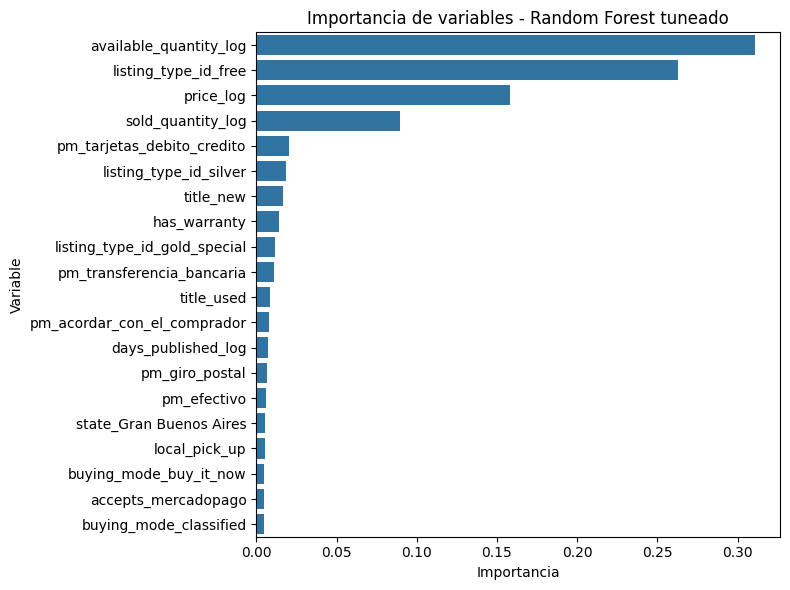

In [ ]:
# Definimos las importancias de las variables del modelo tuneado
importances = rf_best.feature_importances_

# Las ordenamos de mayor a menor y nos quedamos con el top 20
idx_sorted = np.argsort(importances)[::-1][:20]

top_importances = importances[idx_sorted]
top_features    = X_train_scaled.columns[idx_sorted]

# Graficamos las variables
plt.figure(figsize=(8, 6))
sns.barplot(x=top_importances, y=top_features)
plt.title('Importancia de variables - Random Forest tuneado')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()



Con el grafico podemos ver  lasimportancias de las variables del modelo de Random Forest tuneado. Se observa que unas pocas variables concentran casi todo el poder explicativo del modelo:

* available_quantity_log es la variable más importante, con una importancia cercana al 0,31. Esto indica que la cantidad disponible del producto es el factor que más utiliza el modelo para distinguir entre publicaciones de productos nuevos y usados.

* listing_type_id_free aparece como la segunda variable más relevante (≈ 0,26), lo que sugiere que el tipo de publicación gratuita tiene un rol fuerte en la diferenciación de la condición del producto.

* price_log ocupa el tercer lugar (≈ 0,16), mostrando que el precio también aporta información importante para la clasificación.

* sold_quantity_log tiene una importancia intermedia (≈ 0,10), indicando que la cantidad vendida contribuye, aunque en menor medida, a separar ambas clases.

Luego aparecen variables con importancia más baja, como pm_tarjetas_debito_credito, listing_type_id_silver, title_new, has_warranty, listing_type_id_gold_special y pm_transferencia_bancaria, además de title_used, days_published_log y distintos medios de pago y modalidades de compra (pm_acordar_con_el_comprador, pm_giro_postal, pm_efectivo, local_pick_up, buying_mode_buy_it_now, etc.).

Si bien estas variables tienen un peso individual reducido, el conjunto de todas ellas aporta información adicional al modelo.

En resumen, el Random Forest tuneado basa gran parte de sus decisiones en la cantidad disponible, el tipo de publicación (free), el precio y la cantidad vendida, mientras que el resto de variables actúa como información complementaria.